# Phase 0 — Project Context and Assumptions

## Project Objective
This project applies data mining and clustering techniques to customer complaint data
for learning and methodological demonstration purposes.

## Key Assumptions
- The dataset is synthetically generated.
- Complaint texts are template-based and repeated.
- Sentiment and category labels are not semantically grounded in the text.
- Analytical results demonstrate *how techniques work*, not real customer behavior.

## Implication
All insights are interpreted as methodological outcomes rather than operational findings.


In [61]:
PROJECT_ASSUMPTIONS = {
    "data_type": "synthetic",
    "text_variability": "low",
    "label_semantics": "weak",
    "analysis_goal": "methodological_demonstration"
}

PROJECT_ASSUMPTIONS


{'data_type': 'synthetic',
 'text_variability': 'low',
 'label_semantics': 'weak',
 'analysis_goal': 'methodological_demonstration'}

In [62]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

df = pd.read_csv("algerietelecom.csv")

df.head(20)


,id,date,wilaya,canal,texte_reclamation,categorie,sentiment,urgence,status,suggested_action
0,105001,2024-07-31,Tizi Ouzou,Centre d'appel,Incident: modem ne se synchronise pas.,Coupure de ligne,Négatif,Moyenne,Résolu,Redémarrage du modem
1,105002,2024-10-29,Boumerdès,Application mobile,Client signale problème lors de la résiliation...,Résiliation,Négatif,Moyenne,En cours,Vérifier décodeur
2,105003,2024-03-22,Msila,Site web,Demande d'assistance: bruit important sur la l...,Coupure de ligne,Négatif,Basse,Résolu,Envoi technicien
3,105004,2024-04-15,Saïda,Centre d'appel,"Incident: problème lors de la résiliation, fac...",Coupure de ligne,Négatif,Moyenne,Nouveau,Vérifier décodeur
4,105005,2025-09-04,Boumerdès,Site web,Incident: installation non réalisée dans les d...,Coupure de ligne,Négatif,Basse,Clôturé,Vérifier décodeur
5,105006,2024-09-06,Tiaret,Agence commerciale,Demande d'assistance: image figée sur certaine...,Installation,Neutre,Moyenne,Résolu,Planifier rendez-vous
6,105007,2024-07-30,Constantine,Centre d'appel,Demande d'assistance: montant facturé incorrec...,Facturation,Négatif,Moyenne,En cours,Planifier rendez-vous
7,105008,2024-03-26,Médéa,Site web,"Réclamation: montant facturé incorrectement, d...",Coupure de ligne,Négatif,Moyenne,Résolu,Envoi technicien
8,105009,2025-02-28,Blida,Centre d'appel,Client signale demande d'information sur l'off...,Internet lent,Neutre,élevée,Résolu,Ouverture dossier
9,105010,2024-11-07,Alger,Centre d'appel,Réclamation: erreur d'authentification lors de...,Résiliation,Négatif,Moyenne,Résolu,Envoi technicien


In [63]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (100000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   id                 100000 non-null  int64 
 1   date               100000 non-null  object
 2   wilaya             100000 non-null  object
 3   canal              100000 non-null  object
 4   texte_reclamation  100000 non-null  object
 5   categorie          100000 non-null  object
 6   sentiment          100000 non-null  object
 7   urgence            100000 non-null  object
 8   status             100000 non-null  object
 9   suggested_action   100000 non-null  object
dtypes: int64(1), object(9)
memory usage: 7.6+ MB


In [64]:
cardinality = df.nunique().sort_values(ascending=False)

cardinality.to_frame(name="unique_values")


,unique_values
id,100000
date,659
texte_reclamation,50
wilaya,27
categorie,10
suggested_action,8
canal,5
status,5
urgence,4
sentiment,3


In [65]:
(cardinality / len(df)).to_frame(name="uniqueness_ratio")


,uniqueness_ratio
id,1.00000
date,0.00659
texte_reclamation,0.00050
wilaya,0.00027
categorie,0.00010
suggested_action,0.00008
canal,0.00005
status,0.00005
urgence,0.00004
sentiment,0.00003


In [66]:
unique_texts = df["texte_reclamation"].nunique()
total_rows = len(df)

print("Unique texts:", unique_texts)
print("Total rows:", total_rows)
print("Repetition ratio:", total_rows / unique_texts)


Unique texts: 50
Total rows: 100000
Repetition ratio: 2000.0


In [67]:
df["text_prefix"] = df["texte_reclamation"].str.split(":").str[0]

df["text_prefix"].value_counts()


text_prefix
Réclamation                                                                20145
Incident                                                                   19927
Demande d'assistance                                                       19855
Abonné rapporte demande d'information sur l'offre et le contrat.            2050
Client signale coupure de service depuis ce matin.                          2037
Client signale image figée sur certaines chaines.                           2034
Client signale bruit important sur la ligne téléphonique.                   2033
Client signale débit très faible en soirée.                                 2032
Abonné rapporte modem ne se synchronise pas.                                2026
Abonné rapporte débit très faible en soirée.                                2017
Client signale erreur d'authentification lors de la connexion.              2016
Abonné rapporte image figée sur certaines chaines.                          2002
Abonné rapporte 

In [68]:
text_category_counts = (
    df.groupby(["texte_reclamation", "categorie"])
      .size()
      .reset_index(name="count")
)

text_category_counts.head(10)


,texte_reclamation,categorie,count
0,Abonné rapporte bruit important sur la ligne t...,Assistance,157
1,Abonné rapporte bruit important sur la ligne t...,Autre,32
2,Abonné rapporte bruit important sur la ligne t...,Configuration,81
3,Abonné rapporte bruit important sur la ligne t...,Coupure de ligne,452
4,Abonné rapporte bruit important sur la ligne t...,Facturation,253
5,Abonné rapporte bruit important sur la ligne t...,Installation,179
6,Abonné rapporte bruit important sur la ligne t...,Internet lent,429
7,Abonné rapporte bruit important sur la ligne t...,Problème matériel,120
8,Abonné rapporte bruit important sur la ligne t...,Résiliation,96
9,Abonné rapporte bruit important sur la ligne t...,Télévision,196


In [69]:
(
    text_category_counts
    .groupby("texte_reclamation")
    .size()
    .describe()
)


count    50.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
dtype: float64

In [70]:
sentiment_by_category = (
    df.groupby(["categorie", "sentiment"])
      .size()
      .unstack(fill_value=0)
)

sentiment_by_category


sentiment,Neutre,Négatif,Positif
categorie,,,
Assistance,2331,4735,842
Autre,582,1180,204
Configuration,1147,2385,422
Coupure de ligne,6692,13471,2212
Facturation,3530,7213,1148
Installation,2978,5906,987
Internet lent,5947,12122,1965
Problème matériel,1836,3455,588
Résiliation,1834,3646,621


In [71]:
sentiment_by_category.div(sentiment_by_category.sum(axis=1), axis=0)


sentiment,Neutre,Négatif,Positif
categorie,,,
Assistance,0.294765,0.598761,0.106474
Autre,0.296033,0.600203,0.103764
Configuration,0.290086,0.603187,0.106727
Coupure de ligne,0.299084,0.602056,0.098860
Facturation,0.296863,0.606593,0.096544
Installation,0.301692,0.598318,0.099990
Internet lent,0.296845,0.605071,0.098083
Problème matériel,0.312298,0.587685,0.100017
Résiliation,0.300606,0.597607,0.101787


In [72]:
df["categorie"].value_counts(normalize=True)


categorie
Coupure de ligne     0.22375
Internet lent        0.20034
Facturation          0.11891
Télévision           0.10021
Installation         0.09871
Assistance           0.07908
Résiliation          0.06101
Problème matériel    0.05879
Configuration        0.03954
Autre                0.01966
Name: proportion, dtype: float64

## Phase 1 Conclusion — Data Audit

The audit confirms that the dataset is synthetically generated:
- Complaint texts are highly repetitive and template-based
- Each text appears across all categories
- Sentiment labels are weakly correlated with complaint semantics
- Category distribution is smooth and controlled

Despite these limitations, the dataset is suitable for demonstrating
EDA, text processing, and clustering workflows.


# PHASE A — Enhanced EDA & Basic Reporting

This section upgrades the notebook from a methodological demo to a more **business-intelligence-oriented** analysis by adding:
- Descriptive statistics and operational KPIs
- A compact visualization dashboard
- Cross-dimensional analysis (category × urgency, channel × status, region × category)

In [73]:
# === A1: Basic Complaint Statistics ===
import pandas as pd
import numpy as np

print("=" * 50)
print("BASIC COMPLAINT STATISTICS")
print("=" * 50)

print(f"Total complaints: {len(df):,}")

# Ensure date is datetime (Phase A is before Phase 2, so be defensive)
if "date" in df.columns:
    if not np.issubdtype(df["date"].dtype, np.datetime64):
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    print(f"Time period: {df['date'].min()} to {df['date'].max()}")
else:
    print("Time period: (no 'date' column found)")

for col, label in [("categorie", "categories"), ("wilaya", "regions"), ("canal", "channels")]:
    if col in df.columns:
        print(f"Unique {label}: {df[col].nunique()}")
    else:
        print(f"Unique {label}: (no '{col}' column found)")

# Complaint volume over time
if "date" in df.columns:
    df["month"] = df["date"].dt.to_period("M")
    monthly_complaints = df.groupby("month").size()
    print(f"Average complaints per month: {monthly_complaints.mean():.0f}")
else:
    monthly_complaints = None

# Resolution statistics
if "status" in df.columns:
    resolution_rate = (df["status"].astype(str).str.strip().str.lower() == "résolu").mean() * 100
    print(f"Overall resolution rate: {resolution_rate:.1f}%")
else:
    print("Overall resolution rate: (no 'status' column found)")

BASIC COMPLAINT STATISTICS
Total complaints: 100,000
Time period: 2024-01-01 00:00:00 to 2025-10-20 00:00:00
Unique categories: 10
Unique regions: 27
Unique channels: 5
Average complaints per month: 4545
Overall resolution rate: 35.0%


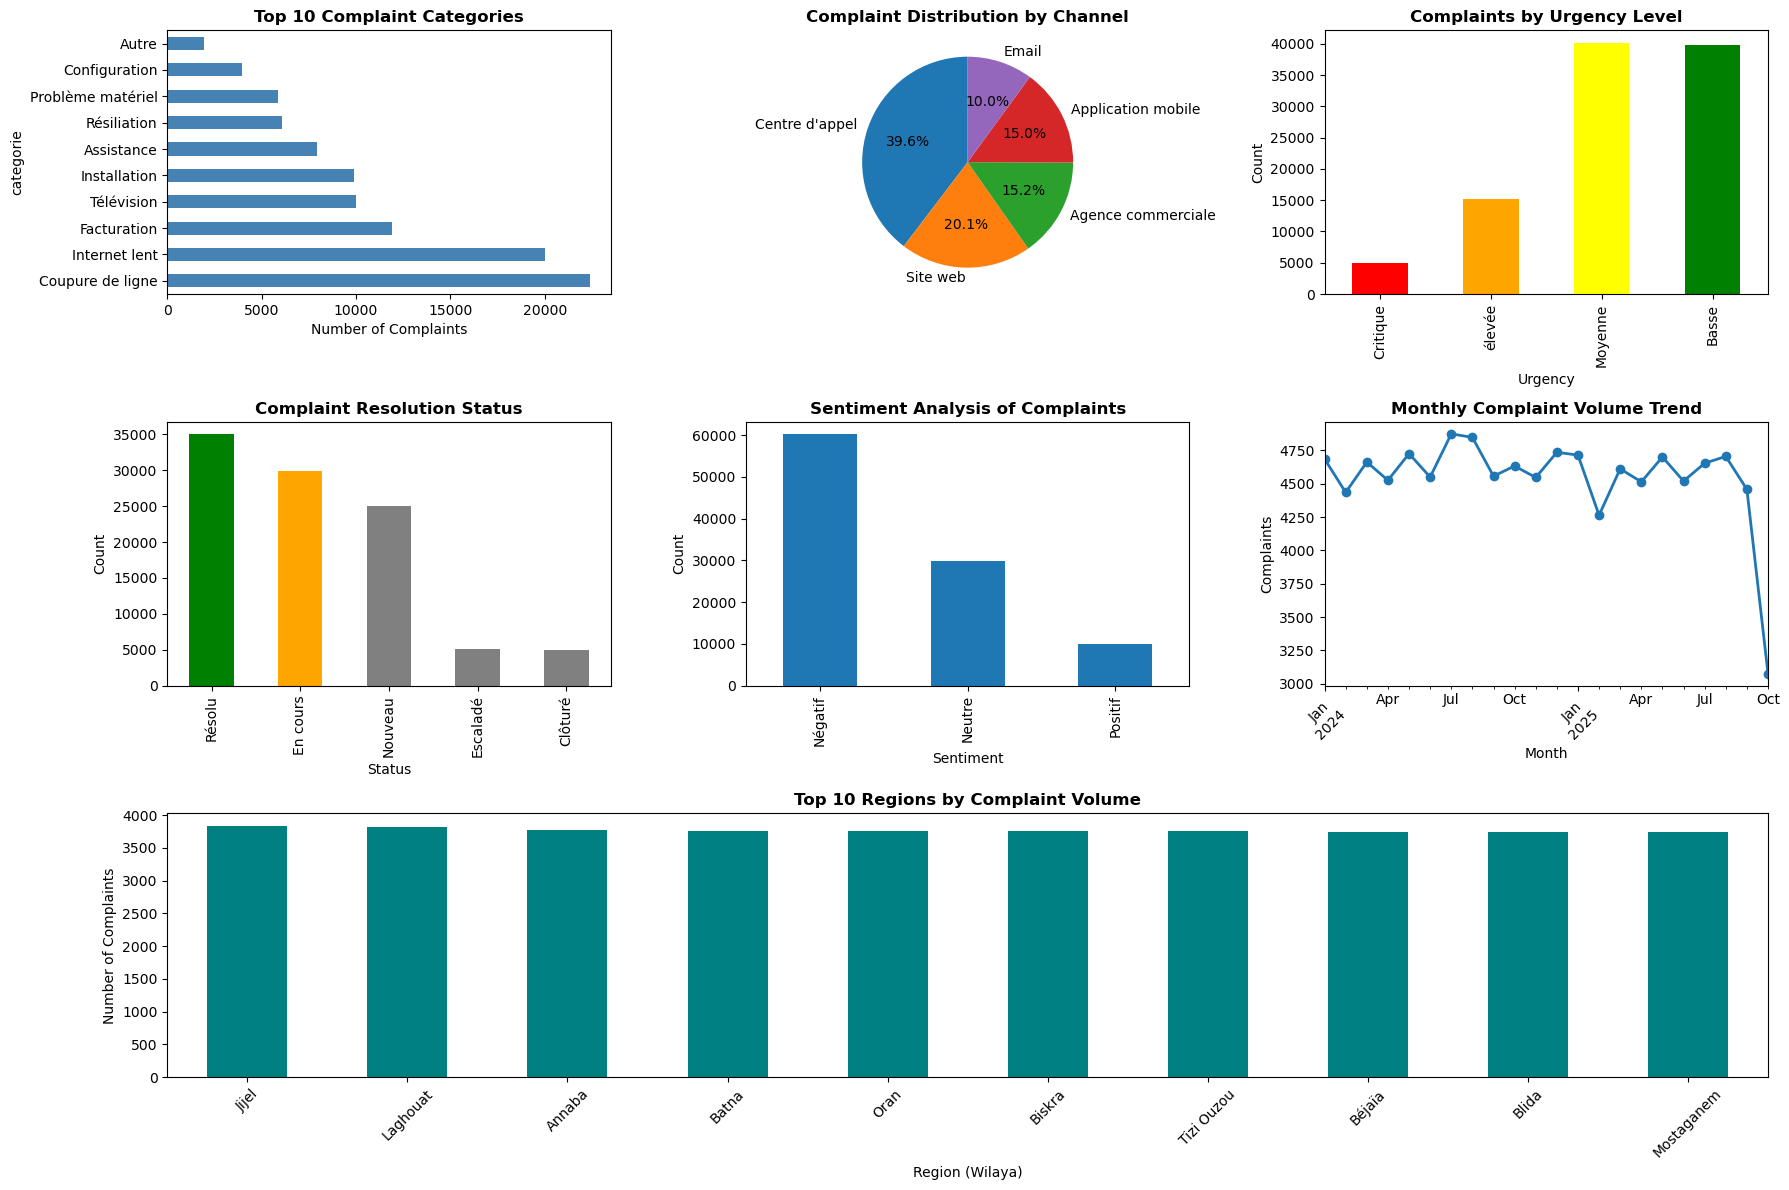

In [74]:
# === A2: Visualization Dashboard ===
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 3, figure=fig)

# 1. Complaints by Category (Top 10)
ax1 = fig.add_subplot(gs[0, 0])
if "categorie" in df.columns:
    category_counts = df["categorie"].value_counts().head(10)
    category_counts.plot(kind="barh", ax=ax1, color="steelblue")
    ax1.set_title("Top 10 Complaint Categories", fontweight="bold")
    ax1.set_xlabel("Number of Complaints")
else:
    ax1.text(0.5, 0.5, "No 'categorie' column", ha="center", va="center")
    ax1.axis("off")

# 2. Complaints by Channel
ax2 = fig.add_subplot(gs[0, 1])
if "canal" in df.columns:
    channel_counts = df["canal"].value_counts()
    channel_counts.plot(kind="pie", ax=ax2, autopct="%1.1f%%", startangle=90)
    ax2.set_title("Complaint Distribution by Channel", fontweight="bold")
    ax2.set_ylabel("")
else:
    ax2.text(0.5, 0.5, "No 'canal' column", ha="center", va="center")
    ax2.axis("off")

# 3. Complaints by Urgency Level
ax3 = fig.add_subplot(gs[0, 2])
if "urgence" in df.columns:
    urgency_order = ["Critique", "élevée", "Moyenne", "Basse"]
    urgency_counts = df["urgence"].value_counts().reindex(urgency_order).fillna(0)
    urgency_counts.plot(kind="bar", ax=ax3, color=["red", "orange", "yellow", "green"])
    ax3.set_title("Complaints by Urgency Level", fontweight="bold")
    ax3.set_xlabel("Urgency")
    ax3.set_ylabel("Count")
else:
    ax3.text(0.5, 0.5, "No 'urgence' column", ha="center", va="center")
    ax3.axis("off")

# 4. Resolution Status
ax4 = fig.add_subplot(gs[1, 0])
if "status" in df.columns:
    status_counts = df["status"].value_counts()
    colors = [
        "green" if str(s).strip() == "Résolu" else "orange" if str(s).strip() == "En cours" else "gray"
        for s in status_counts.index
    ]
    status_counts.plot(kind="bar", ax=ax4, color=colors)
    ax4.set_title("Complaint Resolution Status", fontweight="bold")
    ax4.set_xlabel("Status")
    ax4.set_ylabel("Count")
else:
    ax4.text(0.5, 0.5, "No 'status' column", ha="center", va="center")
    ax4.axis("off")

# 5. Sentiment Distribution
ax5 = fig.add_subplot(gs[1, 1])
if "sentiment" in df.columns:
    sentiment_counts = df["sentiment"].value_counts()
    sentiment_counts.plot(kind="bar", ax=ax5)
    ax5.set_title("Sentiment Analysis of Complaints", fontweight="bold")
    ax5.set_xlabel("Sentiment")
    ax5.set_ylabel("Count")
else:
    ax5.text(0.5, 0.5, "No 'sentiment' column", ha="center", va="center")
    ax5.axis("off")

# 6. Monthly Complaint Trends
ax6 = fig.add_subplot(gs[1, 2])
if "date" in df.columns:
    monthly_trend = df.groupby(df["date"].dt.to_period("M")).size()
    monthly_trend.plot(ax=ax6, marker="o", linewidth=2)
    ax6.set_title("Monthly Complaint Volume Trend", fontweight="bold")
    ax6.set_xlabel("Month")
    ax6.set_ylabel("Complaints")
    ax6.tick_params(axis="x", rotation=45)
else:
    ax6.text(0.5, 0.5, "No 'date' column", ha="center", va="center")
    ax6.axis("off")

# 7. Top 10 Regions by Complaint Volume
ax7 = fig.add_subplot(gs[2, :])
if "wilaya" in df.columns:
    region_counts = df["wilaya"].value_counts().head(10)
    region_counts.plot(kind="bar", ax=ax7, color="teal")
    ax7.set_title("Top 10 Regions by Complaint Volume", fontweight="bold")
    ax7.set_xlabel("Region (Wilaya)")
    ax7.set_ylabel("Number of Complaints")
    ax7.tick_params(axis="x", rotation=45)
else:
    ax7.text(0.5, 0.5, "No 'wilaya' column", ha="center", va="center")
    ax7.axis("off")

plt.tight_layout()
plt.show()

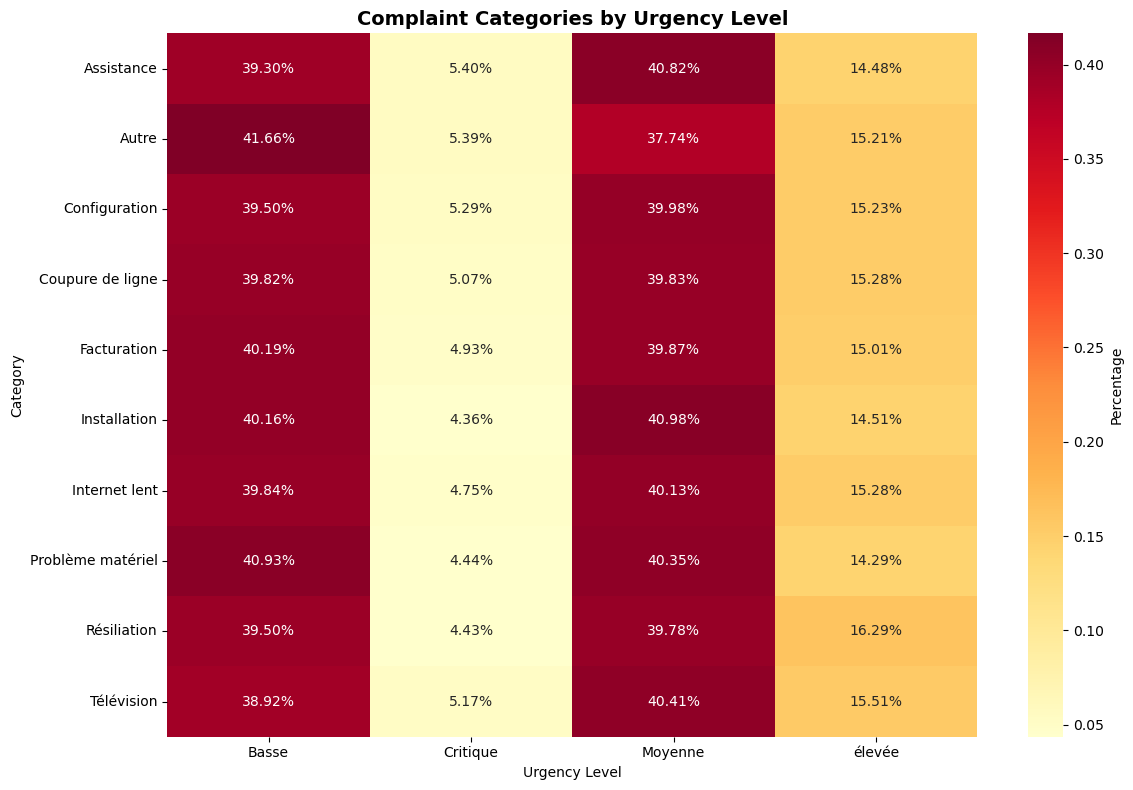


RESOLUTION RATE BY SUBMISSION CHANNEL
status              Clôturé  En cours  Escaladé  Nouveau  Résolu
canal                                                           
Agence commerciale      4.8      29.6       5.2     24.6    35.7
Application mobile      5.2      30.1       4.7     24.7    35.3
Centre d'appel          4.8      29.9       5.2     25.2    34.9
Email                   5.0      30.1       5.3     25.6    34.1
Site web                5.1      30.3       4.9     24.9    34.9


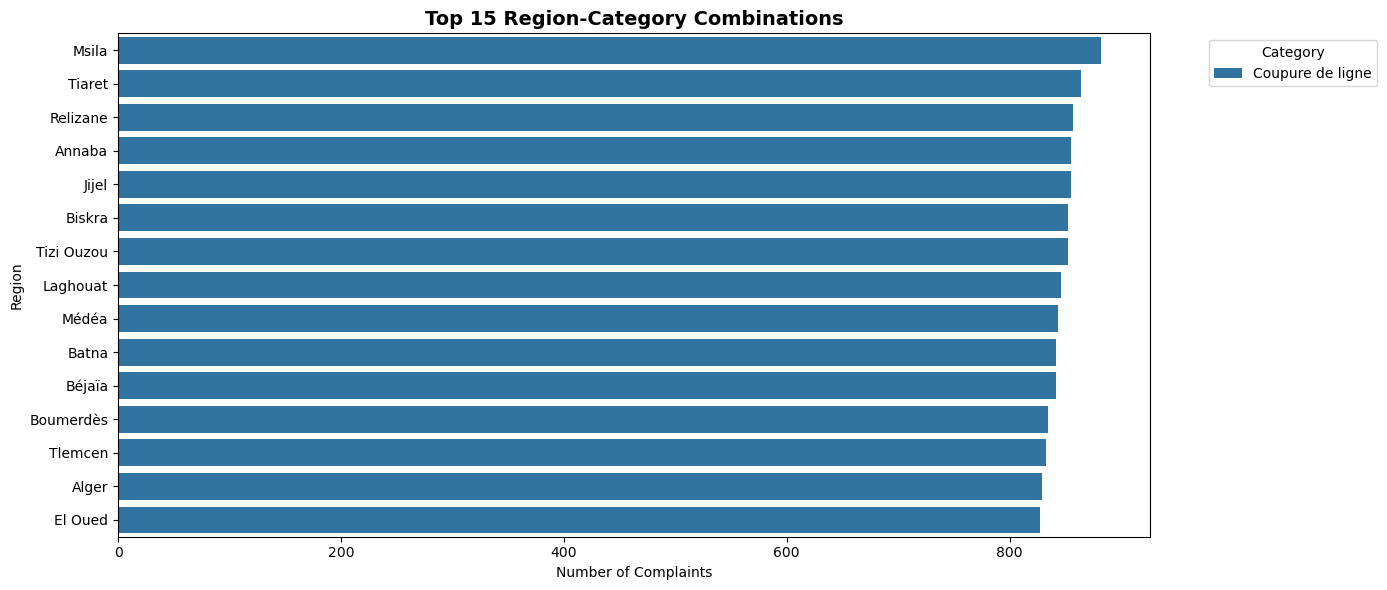

In [75]:
# === A3: Heatmaps and Cross-Tabulations ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Category × Urgency Heatmap
if "categorie" in df.columns and "urgence" in df.columns:
    category_urgency = pd.crosstab(df["categorie"], df["urgence"], normalize="index")
    plt.figure(figsize=(12, 8))
    sns.heatmap(category_urgency, annot=True, fmt=".2%", cmap="YlOrRd", cbar_kws={"label": "Percentage"})
    plt.title("Complaint Categories by Urgency Level", fontsize=14, fontweight="bold")
    plt.xlabel("Urgency Level")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Category × Urgency heatmap (missing 'categorie' or 'urgence').")

# 2. Channel × Status Analysis
if "canal" in df.columns and "status" in df.columns:
    channel_status = pd.crosstab(df["canal"], df["status"], normalize="index") * 100
    print("\n" + "=" * 60)
    print("RESOLUTION RATE BY SUBMISSION CHANNEL")
    print("=" * 60)
    print(channel_status.round(1).to_string())
else:
    channel_status = None
    print("Skipping Channel × Status analysis (missing 'canal' or 'status').")

# 3. Region × Category Analysis (Top combinations)
if "wilaya" in df.columns and "categorie" in df.columns:
    region_category = df.groupby(["wilaya", "categorie"]).size().reset_index(name="count")
    top_combinations = region_category.nlargest(15, "count")

    plt.figure(figsize=(14, 6))
    sns.barplot(data=top_combinations, x="count", y="wilaya", hue="categorie", palette="tab20")
    plt.title("Top 15 Region-Category Combinations", fontsize=14, fontweight="bold")
    plt.xlabel("Number of Complaints")
    plt.ylabel("Region")
    plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Region × Category chart (missing 'wilaya' or 'categorie').")

## Phase 2 — Data Preparation & Feature Engineering

In [76]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure categorical columns are strings
categorical_cols = [
    "wilaya", "canal", "categorie",
    "sentiment", "urgence", "status",
    "suggested_action"
]

df[categorical_cols] = df[categorical_cols].astype(str)

df.dtypes


id                            int64
date                 datetime64[ns]
wilaya                       object
canal                        object
texte_reclamation            object
categorie                    object
sentiment                    object
urgence                      object
status                       object
suggested_action             object
text_prefix                  object
month                     period[M]
dtype: object

In [77]:
import re

def basic_text_cleaning(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)   # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [78]:
df["clean_text"] = df["texte_reclamation"].apply(basic_text_cleaning)

df[["texte_reclamation", "clean_text"]].head()


,texte_reclamation,clean_text
0,Incident: modem ne se synchronise pas.,incident modem ne se synchronise pas
1,Client signale problème lors de la résiliation...,client signale problème lors de la résiliation...
2,Demande d'assistance: bruit important sur la l...,demande d assistance bruit important sur la li...
3,"Incident: problème lors de la résiliation, fac...",incident problème lors de la résiliation factu...
4,Incident: installation non réalisée dans les d...,incident installation non réalisée dans les dé...


In [79]:
TEXT_FEATURE = "clean_text"

META_FEATURES = [
    "wilaya",
    "canal",
    "urgence",
    "status"
]

LABEL_COLUMNS = [
    "categorie",
    "sentiment"
]


In [80]:

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Make sure text has no missing values
df[TEXT_FEATURE] = df[TEXT_FEATURE].fillna("")

# Option A (recommended): NLTK French stopwords (downloads once)
try:
    import nltk
    from nltk.corpus import stopwords

    nltk.download("stopwords", quiet=True)
    french_stop_words = stopwords.words("french")
except Exception:
    # Fallback: small built-in French stopword list (minimal)
    french_stop_words = [
        "a", "au", "aux", "avec", "ce", "ces", "dans", "de", "des", "du", "elle", "en",
        "et", "eux", "il", "je", "la", "le", "les", "leur", "lui", "ma", "mais", "me",
        "meme", "mes", "moi", "mon", "ne", "nos", "notre", "nous", "on", "ou", "par",
        "pas", "pour", "qu", "que", "qui", "sa", "se", "ses", "son", "sur", "ta", "te",
        "tes", "toi", "ton", "tu", "un", "une", "vos", "votre", "vous", "y", "à", "ça",
        "c", "d", "j", "l", "m", "n", "s", "t"
    ]

tfidf_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.9,
            stop_words=french_stop_words,  # <-- list, not "french"
        ))
    ]
)

X_text_tfidf = tfidf_pipeline.fit_transform(df[TEXT_FEATURE])
X_text_tfidf.shape


(100000, 128)

In [81]:

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# sklearn >= 1.2 uses sparse_output; older versions use sparse
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

metadata_pipeline = ColumnTransformer(
    transformers=[
        ("cat", ohe, META_FEATURES)
    ]
)

metadata_pipeline
X_meta = metadata_pipeline.fit_transform(df)

X_meta.shape


(100000, 41)

In [82]:
from scipy.sparse import hstack

X_hybrid = hstack([X_text_tfidf, X_meta])

X_hybrid.shape


(100000, 169)

In [83]:
print("Text features:", X_text_tfidf.shape)
print("Metadata features:", X_meta.shape)
print("Hybrid features:", X_hybrid.shape)


Text features: (100000, 128)
Metadata features: (100000, 41)
Hybrid features: (100000, 169)


## Phase 2 Conclusion — Feature Preparation

The dataset required minimal cleaning due to its synthetic nature.
This phase focused on constructing standardized and reusable feature
representations using scikit-learn pipelines.

Three feature spaces were prepared:
- TF-IDF text features
- Encoded metadata features
- Hybrid text + metadata features

These representations enable fair and systematic comparison of multiple
clustering algorithms in subsequent phases.


# PHASE B — Simple Text Analysis (Keywords & Phrases)

This section provides **student-level text mining** outputs requested in most briefs:
- Most frequent keywords
- Most frequent phrases (bigrams)
- Keyword breakdown by category and by sentiment
- Optional word cloud (runs only if `wordcloud` is installed)

In [84]:
# === B1/B2: Basic Text Mining (keywords + bigrams) ===
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base stopwords list is already defined earlier as `french_stop_words` (list).
# Extend with a small domain-specific stopword set.
domain_stopwords = {
    "client", "signale", "abonné", "abonne", "rapporte", "incident", "réclamation", "reclamation",
    "demande", "assistance", "svp", "merci", "bonjour", "salut", "urgent", "urgence"
}
_base_stopwords = set(map(str, globals().get("french_stop_words", [])))
stop_set = _base_stopwords | domain_stopwords

word_re = re.compile(r"\b[a-zàâçéèêëîïôûùüÿæœ]+\b", re.IGNORECASE)

def extract_words(text: str):
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return []
    words = word_re.findall(str(text).lower())
    return [w for w in words if w not in stop_set and len(w) > 2]

text_col = "clean_text" if "clean_text" in df.columns else ("texte_reclamation" if "texte_reclamation" in df.columns else None)
if text_col is None:
    raise ValueError("No text column found: expected 'clean_text' or 'texte_reclamation'.")

all_words = []
for t in df[text_col].astype(str).tolist():
    all_words.extend(extract_words(t))

word_freq = Counter(all_words)

print("=" * 50)
print("TOP 20 MOST FREQUENT WORDS IN COMPLAINTS")
print("=" * 50)
for word, count in word_freq.most_common(20):
    print(f"{word:20} : {count:>6,}")

# --- Optional word cloud ---
try:
    from wordcloud import WordCloud
    wc_text = " ".join(df[text_col].astype(str).tolist())
    plt.figure(figsize=(12, 6))
    wordcloud = WordCloud(
        width=900, height=450,
        background_color="white",
        stopwords=stop_set,
        max_words=120,
    ).generate(wc_text)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Customer Complaints", fontsize=16, fontweight="bold")
    plt.show()
except Exception as e:
    print("\n[WordCloud skipped] Install with: %pip install wordcloud")
    print("Reason:", repr(e))

# --- Bigram phrases (no NLTK required) ---
def extract_bigrams(text: str):
    words = extract_words(text)
    return list(zip(words, words[1:])) if len(words) >= 2 else []

all_bigrams = []
for t in df[text_col].astype(str).tolist():
    all_bigrams.extend(extract_bigrams(t))

bigram_freq = Counter(all_bigrams)

print("\n" + "=" * 50)
print("TOP 20 MOST FREQUENT PHRASES (BIGRAMS)")
print("=" * 50)
for phrase, count in bigram_freq.most_common(20):
    print(f"{' '.join(phrase):30} : {count:>6,}")

TOP 20 MOST FREQUENT WORDS IN COMPLAINTS
lors                 : 19,905
image                : 10,112
figée                : 10,112
certaines            : 10,112
chaines              : 10,112
montant              : 10,066
facturé              : 10,066
incorrectement       : 10,066
régularisation       : 10,066
bruit                : 10,048
important            : 10,048
ligne                : 10,048
téléphonique         : 10,048
débit                : 10,034
très                 : 10,034
faible               : 10,034
soirée               : 10,034
installation         : 10,017
non                  : 10,017
réalisée             : 10,017

[WordCloud skipped] Install with: %pip install wordcloud
Reason: ModuleNotFoundError("No module named 'wordcloud'")

TOP 20 MOST FREQUENT PHRASES (BIGRAMS)
image figée                    : 10,112
figée certaines                : 10,112
certaines chaines              : 10,112
montant facturé                : 10,066
facturé incorrectement         : 10,066
in

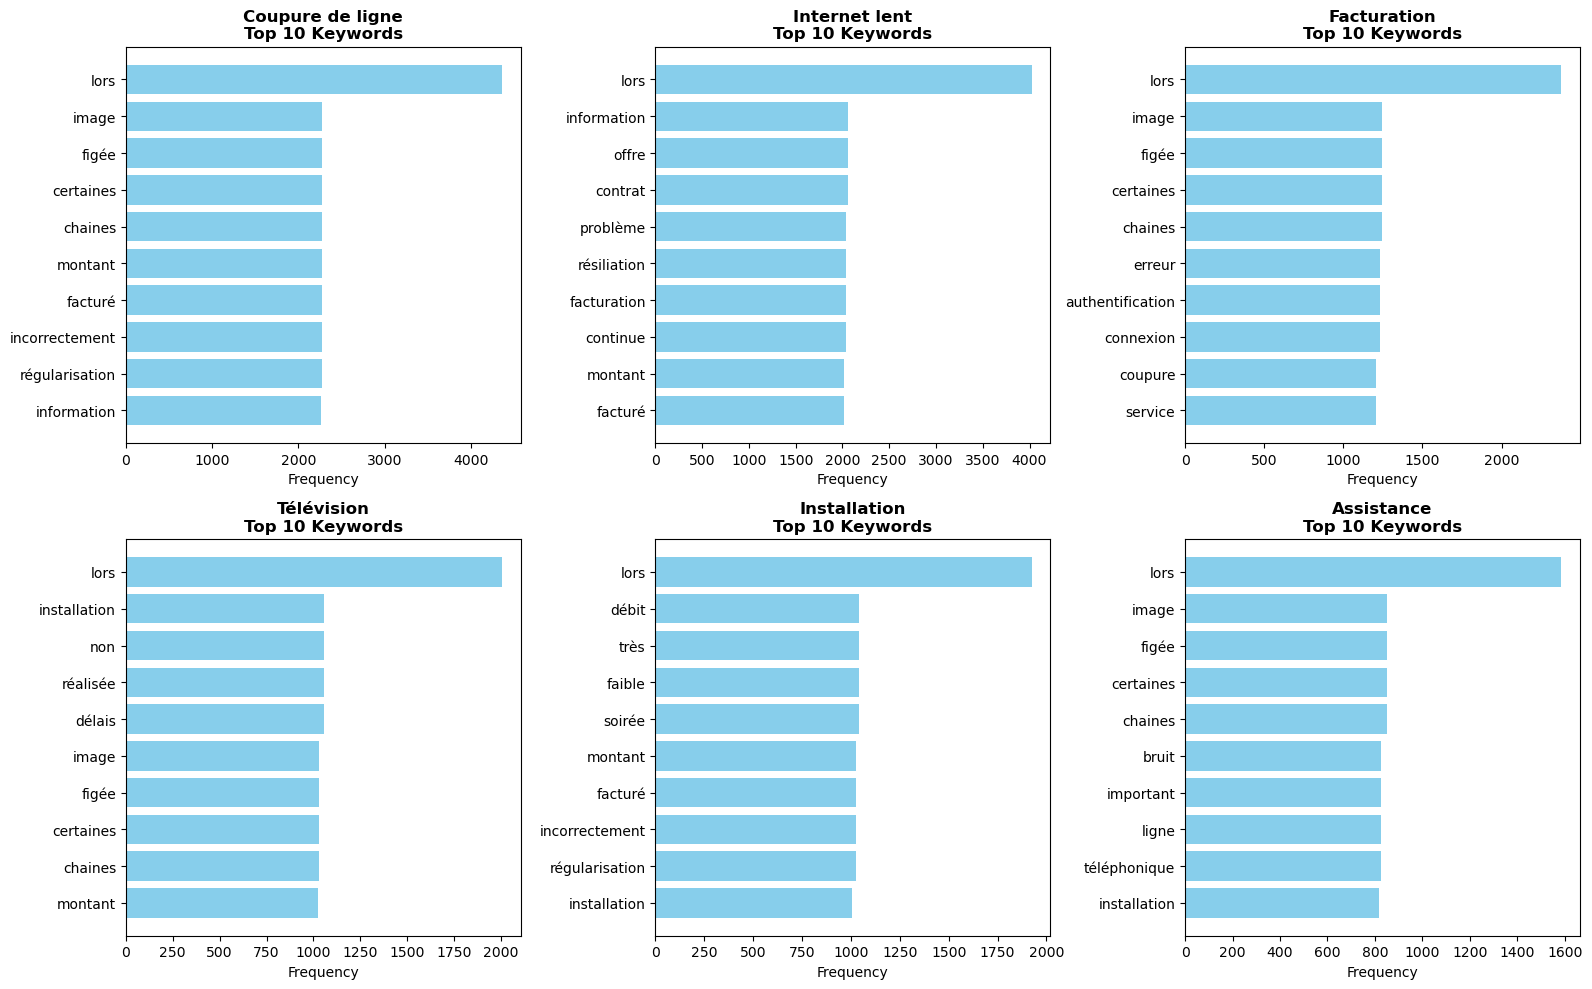

In [85]:
# === B3: Text Analysis by Category (Top keywords) ===
import matplotlib.pyplot as plt
import numpy as np

if "categorie" not in df.columns:
    print("Skipping B3 (no 'categorie' column).")
else:
    top_categories = df["categorie"].value_counts().head(6).index.tolist()
    n = len(top_categories)
    if n == 0:
        print("No categories found.")
    else:
        rows = 2
        cols = 3
        fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
        axes = np.array(axes).ravel()

        for i_ax, category in enumerate(top_categories):
            ax = axes[i_ax]
            cat_texts = df.loc[df["categorie"] == category, text_col].astype(str).tolist()
            words = []
            for t in cat_texts:
                words.extend(extract_words(t))
            wf = Counter(words)
            top_words = wf.most_common(10)
            if not top_words:
                ax.axis("off")
                ax.set_title(f"{category}\n(no keywords)")
                continue
            words_list, counts = zip(*top_words)
            ax.barh(range(len(words_list)), counts, color="skyblue")
            ax.set_yticks(range(len(words_list)))
            ax.set_yticklabels(words_list)
            ax.invert_yaxis()
            ax.set_title(f"{category}\nTop 10 Keywords", fontweight="bold")
            ax.set_xlabel("Frequency")

        # hide unused axes
        for j in range(n, rows * cols):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

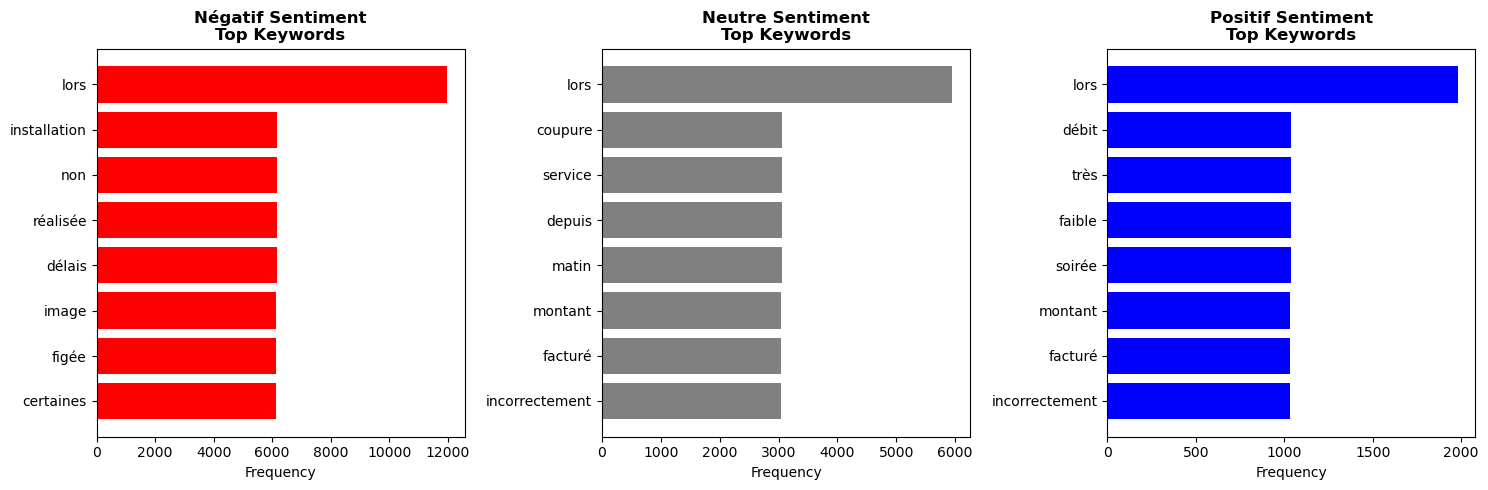


UNIQUE WORDS CHARACTERISTIC OF EACH SENTIMENT (first 10):
------------------------------------------------------------
Négatif   : ...
Neutre    : ...
Positif   : ...


In [86]:
# === B4: Text Analysis by Sentiment (Top keywords + unique words) ===
import matplotlib.pyplot as plt
import numpy as np

if "sentiment" not in df.columns:
    print("Skipping B4 (no 'sentiment' column).")
else:
    sentiments = ["Négatif", "Neutre", "Positif"]
    present = [s for s in sentiments if (df["sentiment"].astype(str) == s).any()]
    if not present:
        # fall back to whatever exists
        present = df["sentiment"].astype(str).value_counts().index.tolist()[:3]

    fig, axes = plt.subplots(1, len(present), figsize=(5 * len(present), 5))
    if len(present) == 1:
        axes = [axes]
    colors = {"Négatif": "red", "Neutre": "gray", "Positif": "blue"}

    for i, s in enumerate(present):
        ax = axes[i]
        s_texts = df.loc[df["sentiment"].astype(str) == s, text_col].astype(str).tolist()
        words = []
        for t in s_texts:
            words.extend(extract_words(t))
        wf = Counter(words)
        top_words = wf.most_common(8)
        if not top_words:
            ax.axis("off")
            ax.set_title(f"{s}\n(no keywords)")
            continue
        words_list, counts = zip(*top_words)
        ax.barh(range(len(words_list)), counts, color=colors.get(s, "steelblue"))
        ax.set_yticks(range(len(words_list)))
        ax.set_yticklabels(words_list)
        ax.invert_yaxis()
        ax.set_title(f"{s} Sentiment\nTop Keywords", fontweight="bold")
        ax.set_xlabel("Frequency")

    plt.tight_layout()
    plt.show()

    print("\nUNIQUE WORDS CHARACTERISTIC OF EACH SENTIMENT (first 10):")
    print("-" * 60)
    all_sent_words = {}
    for s in present:
        s_words = set()
        for t in df.loc[df["sentiment"].astype(str) == s, text_col].astype(str).tolist():
            s_words.update(extract_words(t))
        all_sent_words[s] = s_words

    for s in present:
        others = set().union(*[w for k, w in all_sent_words.items() if k != s])
        unique_words = sorted(list(all_sent_words[s] - others))
        preview = ", ".join(unique_words[:10])
        print(f"{s:10}: {preview}...")

# PHASE C — Business Grouping & Pattern Detection

This section adds **business-facing grouping tables** and **pattern detection** before heavy clustering:
- Priority ranking (category × urgency)
- Regional/channel performance tables
- Time-based complaint patterns
- Resolution path counts (category → suggested action)

STRATEGIC GROUPING ANALYSIS FOR SUPPORT OPTIMIZATION

1. CATEGORIES BY URGENCY (Priority Ranking):
------------------------------------------------------------
urgence            Critique  élevée  Moyenne  Basse  Total  Critique_Rate
categorie                                                                
Assistance              427    1145     3228   3108   7908            5.4
Autre                   106     299      742    819   1966            5.4
Configuration           209     602     1581   1562   3954            5.3
Télévision              518    1554     4049   3900  10021            5.2
Coupure de ligne       1135    3419     8912   8909  22375            5.1
Facturation             586    1785     4741   4779  11891            4.9
Internet lent           952    3061     8039   7982  20034            4.8
Installation            430    1432     4045   3964   9871            4.4
Problème matériel       261     840     2372   2406   5879            4.4
Résiliation             27

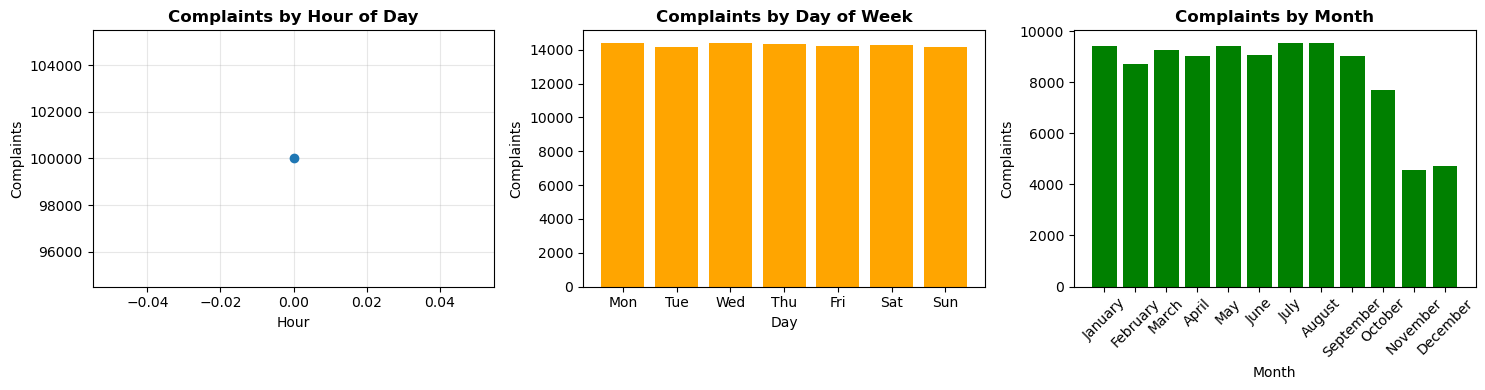

In [87]:
# === C1: Strategic Grouping Analysis ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STRATEGIC GROUPING ANALYSIS FOR SUPPORT OPTIMIZATION")
print("=" * 70)

# Defensive datetime conversion (Phase C is before Phase 3; Phase 2 already converts, but be safe)
if "date" in df.columns and not np.issubdtype(df["date"].dtype, np.datetime64):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Helper flags
if "urgence" in df.columns:
    is_critical = df["urgence"].astype(str).isin(["Critique", "élevée"])
else:
    is_critical = pd.Series(False, index=df.index)

if "status" in df.columns:
    is_resolved = df["status"].astype(str).str.strip().str.lower().eq("résolu")
else:
    is_resolved = pd.Series(False, index=df.index)

if "sentiment" in df.columns:
    is_negative = df["sentiment"].astype(str).str.strip().str.lower().eq("négatif")
else:
    is_negative = pd.Series(False, index=df.index)

# 1) Category-Urgency Priority Matrix
if "categorie" in df.columns and "urgence" in df.columns:
    category_urgency_matrix = pd.crosstab(df["categorie"], df["urgence"])
    category_urgency_matrix["Total"] = category_urgency_matrix.sum(axis=1)
    if "Critique" in category_urgency_matrix.columns:
        category_urgency_matrix["Critique_Rate"] = (
            category_urgency_matrix["Critique"] / category_urgency_matrix["Total"] * 100
        ).round(1)
    else:
        category_urgency_matrix["Critique_Rate"] = np.nan
    category_urgency_matrix = category_urgency_matrix.sort_values("Critique_Rate", ascending=False)

    print("\n1. CATEGORIES BY URGENCY (Priority Ranking):")
    print("-" * 60)
    cols = [c for c in ["Critique", "élevée", "Moyenne", "Basse", "Total", "Critique_Rate"] if c in category_urgency_matrix.columns]
    print(category_urgency_matrix[cols].to_string())
else:
    category_urgency_matrix = None
    print("\n1. Skipping category urgency matrix (missing 'categorie' or 'urgence').")

# 2) Regional Hotspot Analysis
if "wilaya" in df.columns:
    regional_analysis = (
        df.assign(_critical=is_critical, _resolved=is_resolved)
          .groupby("wilaya")
          .agg(
              Total_Complaints=("wilaya", "size"),
              Critical_Rate_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_Rate_pct=("_resolved", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Total_Complaints", ascending=False)
    )

    print("\n\n2. REGIONAL PERFORMANCE ANALYSIS (Top 10 by volume):")
    print("-" * 60)
    print(regional_analysis.head(10).to_string())
else:
    regional_analysis = None
    print("\n\n2. Skipping regional analysis (missing 'wilaya').")

# 3) Channel Effectiveness Analysis
if "canal" in df.columns:
    channel_analysis = (
        df.assign(_critical=is_critical, _resolved=is_resolved, _negative=is_negative)
          .groupby("canal")
          .agg(
              Volume=("canal", "size"),
              Critical_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_pct=("_resolved", lambda x: float(x.mean() * 100)),
              Negative_pct=("_negative", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Volume", ascending=False)
    )

    print("\n\n3. CHANNEL EFFECTIVENESS ANALYSIS:")
    print("-" * 60)
    print(channel_analysis.to_string())
else:
    channel_analysis = None
    print("\n\n3. Skipping channel analysis (missing 'canal').")

# 4) Time-Based Patterns
if "date" in df.columns:
    df["hour"] = df["date"].dt.hour
    df["day_of_week"] = df["date"].dt.day_name()
    df["month_name"] = df["date"].dt.month_name()

    hourly_pattern = df.groupby("hour").size()
    daily_pattern = df.groupby("day_of_week").size()
    monthly_pattern = df.groupby("month_name").size()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(hourly_pattern.index, hourly_pattern.values, marker="o", linewidth=2)
    axes[0].set_title("Complaints by Hour of Day", fontweight="bold")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Complaints")
    axes[0].grid(True, alpha=0.3)

    daily_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    axes[1].bar(range(len(daily_order)), daily_pattern.reindex(daily_order).fillna(0), color="orange")
    axes[1].set_title("Complaints by Day of Week", fontweight="bold")
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Complaints")
    axes[1].set_xticks(range(len(daily_order)))
    axes[1].set_xticklabels([d[:3] for d in daily_order])

    # Order months explicitly
    month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
    monthly_pattern = monthly_pattern.reindex(month_order).fillna(0)
    axes[2].bar(monthly_pattern.index, monthly_pattern.values, color="green")
    axes[2].set_title("Complaints by Month", fontweight="bold")
    axes[2].set_xlabel("Month")
    axes[2].set_ylabel("Complaints")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
else:
    hourly_pattern = daily_pattern = monthly_pattern = None
    print("\n\n4. Skipping time patterns (missing 'date').")

In [88]:
# === C2: Pattern Detection Tables ===
import pandas as pd
import numpy as np

print("=" * 70)
print("KEY PATTERN DETECTION TABLES")
print("=" * 70)

# 1) Most common complaint chains (Category → Suggested Action)
if "categorie" in df.columns and "suggested_action" in df.columns:
    print("\n1. MOST COMMON RESOLUTION PATHS (Category → Suggested Action):")
    print("-" * 60)
    resolution_paths = df.groupby(["categorie", "suggested_action"]).size().reset_index(name="count")
    top_paths = resolution_paths.nlargest(15, "count")
    print(top_paths.to_string(index=False))
else:
    print("\n1. Skipping resolution paths (missing 'categorie' or 'suggested_action').")

# 2) Regional specialization (top category per region)
if "wilaya" in df.columns and "categorie" in df.columns:
    print("\n\n2. REGIONAL SPECIALIZATION (Top Category per Region):")
    print("-" * 60)
    specialization_df = (
        df.groupby(["wilaya", "categorie"]).size().reset_index(name="count")
          .sort_values(["wilaya", "count"], ascending=[True, False])
          .groupby("wilaya").head(1)
          .assign(pct_of_region=lambda d: (d["count"] / d.groupby("wilaya")["count"].transform("sum") * 100).round(1))
    )
    # Note: pct_of_region above would be 100% due to head(1) unless we compute totals separately; do it correctly:
    totals = df.groupby("wilaya").size().rename("region_total")
    specialization_df = specialization_df.merge(totals, left_on="wilaya", right_index=True)
    specialization_df["pct_of_region"] = (specialization_df["count"] / specialization_df["region_total"] * 100).round(1)
    specialization_df = specialization_df.drop(columns=["region_total"])
    print(specialization_df.sort_values("count", ascending=False).head(15).to_string(index=False))
else:
    print("\n\n2. Skipping regional specialization (missing 'wilaya' or 'categorie').")

# 3) Seasonal patterns by category (month_name must exist; otherwise derive from date)
if "date" in df.columns and "categorie" in df.columns:
    if "month_name" not in df.columns:
        df["month_name"] = df["date"].dt.month_name()
    print("\n\n3. SEASONAL PATTERNS BY CATEGORY (peaks):")
    print("-" * 60)
    monthly_category = pd.crosstab(df["month_name"], df["categorie"], normalize="index") * 100
    month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
    monthly_category = monthly_category.reindex(month_order)

    # Highlight categories with notable peaks
    for category in monthly_category.columns:
        series = monthly_category[category].dropna()
        if series.empty:
            continue
        if series.std() > 5:
            peak_month = series.idxmax()
            peak_value = series.max()
            avg_value = series.mean()
            if avg_value > 0 and peak_value > avg_value * 1.2:
                print(f"{category}: peaks in {peak_month} ({peak_value:.1f}% vs avg {avg_value:.1f}%)")
else:
    print("\n\n3. Skipping seasonal patterns (missing 'date' or 'categorie').")

KEY PATTERN DETECTION TABLES

1. MOST COMMON RESOLUTION PATHS (Category → Suggested Action):
------------------------------------------------------------
       categorie         suggested_action  count
Coupure de ligne         Envoi technicien   5533
   Internet lent         Envoi technicien   4870
Coupure de ligne     Redémarrage du modem   4486
   Internet lent     Redémarrage du modem   3981
Coupure de ligne Vérification facturation   3339
   Internet lent Vérification facturation   3118
     Facturation         Envoi technicien   2883
      Télévision         Envoi technicien   2541
    Installation         Envoi technicien   2417
     Facturation     Redémarrage du modem   2375
Coupure de ligne        Vérifier décodeur   2251
      Télévision     Redémarrage du modem   2037
    Installation     Redémarrage du modem   2002
   Internet lent        Vérifier décodeur   1975
      Assistance         Envoi technicien   1917


2. REGIONAL SPECIALIZATION (Top Category per Region):
------

## PHASE 3 — Classical Clustering Baselines

In [89]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer

svd_pipeline = Pipeline(
    steps=[
        ("svd", TruncatedSVD(n_components=100, random_state=42)),
        ("norm", Normalizer(copy=False))
    ]
)

X_svd = svd_pipeline.fit_transform(X_text_tfidf)

X_svd.shape


(100000, 100)

In [90]:
import numpy as np

explained_variance = svd_pipeline.named_steps["svd"].explained_variance_ratio_
print(f"Total explained variance: {np.sum(explained_variance):.2%}")


Total explained variance: 100.00%


In [91]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [5, 8, 10, 12, 15]
results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd)
    
    # LIMIT SAMPLE SIZE TO 10,000 or 5,000
    sil = silhouette_score(X_svd, labels, metric="cosine", sample_size=10000)
    
    results.append((k, kmeans.inertia_, sil))
    print(f"k={k} completed. Inertia: {kmeans.inertia_:.2f}, Sil: {sil:.4f}")

results

k=5 completed. Inertia: 61170.47, Sil: 0.3633
k=8 completed. Inertia: 40732.80, Sil: 0.5701
k=10 completed. Inertia: 27868.85, Sil: 0.7057
k=12 completed. Inertia: 25987.34, Sil: 0.6539
k=15 completed. Inertia: 23061.91, Sil: 0.6563


[(5, 61170.468882542045, 0.36328355380104177),
 (8, 40732.797379818774, 0.5700931058201141),
 (10, 27868.854836183287, 0.7056567471787349),
 (12, 25987.343394537365, 0.6538831847162087),
 (15, 23061.914254472194, 0.656269676498437)]

In [92]:
optimal_k = 10

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

df["kmeans_cluster"] = kmeans.fit_predict(X_svd)


In [93]:
df["kmeans_cluster"].value_counts().sort_index()


kmeans_cluster
0    10017
1    10066
2     9996
3    10034
4     9909
5    10048
6    10112
7     9989
8     9933
9     9896
Name: count, dtype: int64

In [94]:
import pandas as pd
import numpy as np

terms = tfidf_pipeline.named_steps["tfidf"].get_feature_names_out()
centroids = kmeans.cluster_centers_

top_terms = {}

for i in range(optimal_k):
    top_idx = centroids[i].argsort()[-10:][::-1]
    top_terms[i] = [terms[j] for j in top_idx]

pd.DataFrame.from_dict(top_terms, orient="index", columns=[f"term_{i}" for i in range(10)])


,term_0,term_1,term_2,term_3,term_4,term_5,term_6,term_7,term_8,term_9
0,assistance demande,abonné,assistance problème,assistance montant,demande assistance,demande,demande information,coupure service,figée,coupure
1,assistance,abonné,assistance image,assistance problème,assistance bruit,assistance coupure,figée certaines,assistance modem,bruit,authentification
2,abonné rapporte,abonné,assistance,assistance bruit,assistance problème,assistance coupure,assistance montant,assistance modem,image figée,important ligne
3,abonné,assistance problème,assistance montant,demande,demande information,coupure service,coupure,figée,bruit,continue
4,assistance image,abonné rapporte,abonné,assistance erreur,assistance,assistance montant,assistance problème,assistance bruit,continue,assistance coupure
5,assistance coupure,abonné,assistance montant,assistance problème,coupure service,assistance modem,coupure,demande information,figée,bruit
6,assistance bruit,abonné,assistance coupure,assistance problème,assistance montant,coupure,assistance modem,figée,continue,bruit
7,assistance débit,abonné,assistance demande,assistance problème,assistance montant,assistance modem,figée,coupure,coupure service,bruit
8,assistance erreur,abonné,assistance,assistance problème,facturation continue,assistance bruit,assistance coupure,facturé,figée,bruit
9,assistance installation,abonné,assistance montant,assistance erreur,assistance problème,assistance image,assistance débit,assistance demande,authentification,certaines


In [95]:
from sklearn.cluster import AgglomerativeClustering

# 1. Take a random sample of 5,000 rows (sufficient for structure)
sample_indices = np.random.choice(X_svd.shape[0], size=5000, replace=False)
X_sample = X_svd[sample_indices]

# 2. Fit on the sample
agg = AgglomerativeClustering(
    n_clusters=10, 
    metric="cosine", 
    linkage="average"
)
sample_labels = agg.fit_predict(X_sample)

# 3. (Optional) If you absolutely need labels for ALL 100k rows, 
# you can use a NearestNeighbor classifier to propogate labels from the sample to the full dataset.
# But for just visualizing the dendrogram or testing, the sample is enough.

In [96]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# 1. Cluster a Sample (to avoid MemoryError)
sample_indices = np.random.choice(X_svd.shape[0], size=5000, replace=False)
X_sample = X_svd[sample_indices]

agg_sample = AgglomerativeClustering(n_clusters=10, metric="cosine", linkage="average")
y_sample_labels = agg_sample.fit_predict(X_sample)

# 2. Train a KNN to "learn" the clustering logic
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_sample, y_sample_labels)

# 3. Predict clusters for the FULL dataset
df["agg_cluster"] = knn.predict(X_svd)

# Now your comparison code will work:
pd.DataFrame({
    "KMeans": df["kmeans_cluster"].value_counts().sort_index(),
    "Agglomerative": df["agg_cluster"].value_counts().sort_index()
})

,KMeans,Agglomerative
0,10017,9896
1,10066,9933
2,9996,10048
3,10034,9909
4,9909,10017
5,10048,9989
6,10112,10112
7,9989,10034
8,9933,10066
9,9896,9996


In [97]:
from sklearn.metrics import silhouette_score

# Use a sample of 10,000 to get a result in seconds
sil_kmeans = silhouette_score(X_svd, df["kmeans_cluster"], metric="cosine", sample_size=10000)
sil_agg = silhouette_score(X_svd, df["agg_cluster"], metric="cosine", sample_size=10000)

print(f"KMeans Silhouette: {sil_kmeans:.4f}")
print(f"Agglomerative Silhouette: {sil_agg:.4f}")

KMeans Silhouette: 0.7044
Agglomerative Silhouette: 0.7050


In [98]:
for cluster_id in range(3):
    print(f"\n--- Agglomerative Cluster {cluster_id} ---")
    display(
        df[df["agg_cluster"] == cluster_id]["texte_reclamation"]
        .sample(5, random_state=42)
        .values
    )



--- Agglomerative Cluster 0 ---


array(['Client signale modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Réclamation: modem ne se synchronise pas.',
       'Réclamation: modem ne se synchronise pas.',
       "Demande d'assistance: modem ne se synchronise pas."], dtype=object)


--- Agglomerative Cluster 1 ---


array(["Demande d'assistance: demande d'information sur l'offre et le contrat.",
       "Abonné rapporte demande d'information sur l'offre et le contrat.",
       "Client signale demande d'information sur l'offre et le contrat.",
       "Incident: demande d'information sur l'offre et le contrat.",
       "Client signale demande d'information sur l'offre et le contrat."],
      dtype=object)


--- Agglomerative Cluster 2 ---


array(['Réclamation: bruit important sur la ligne téléphonique.',
       'Abonné rapporte bruit important sur la ligne téléphonique.',
       'Client signale bruit important sur la ligne téléphonique.',
       'Incident: bruit important sur la ligne téléphonique.',
       'Incident: bruit important sur la ligne téléphonique.'],
      dtype=object)

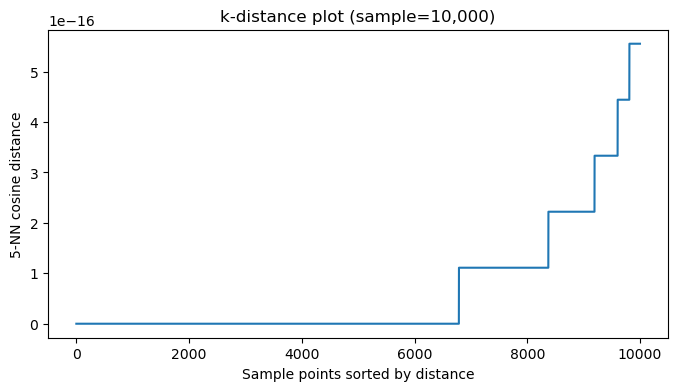

In [99]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# k-distance plot on a SAMPLE (much faster on large datasets)
neighbors = 5
sample_size = 10_000  # change to 5_000 if still slow

rng = np.random.default_rng(42)
n = X_svd.shape[0]
idx = rng.choice(n, size=min(sample_size, n), replace=False)
X_svd_sample = X_svd[idx]

# For cosine distance, brute force is typically used; n_jobs speeds up where supported
nbrs = NearestNeighbors(n_neighbors=neighbors, metric="cosine", algorithm="brute", n_jobs=-1)
nbrs.fit(X_svd_sample)
distances, _ = nbrs.kneighbors(X_svd_sample)

# Sort and plot distances to find elbow
k_dist = np.sort(distances[:, -1])
plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.title(f"k-distance plot (sample={len(X_svd_sample):,})")
plt.xlabel("Sample points sorted by distance")
plt.ylabel(f"{neighbors}-NN cosine distance")
plt.show()

In [100]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.1,         # adjust after observing k-distance plot
    min_samples=5,
    metric="cosine",
    n_jobs=-1
)

df["dbscan_cluster"] = dbscan.fit_predict(X_svd)


In [101]:
df["dbscan_cluster"].value_counts().sort_index()


dbscan_cluster
0     1922
1     1986
2     1944
3     2003
4     2004
5     2048
6     2076
7     2018
8     1991
9     2016
10    1992
11    1984
12    2001
13    1986
14    1984
15    1979
16    1996
17    2034
18    1993
19    2032
20    2009
21    2041
22    1877
23    1998
24    1968
25    1960
26    1922
27    2002
28    1997
29    1984
30    2016
31    2000
32    2033
33    2001
34    1935
35    2037
36    1997
37    2076
38    1992
39    1999
40    1995
41    2087
42    1985
43    2011
44    1984
45    2017
46    2050
47    2017
48    2026
49    1995
Name: count, dtype: int64

In [102]:
from sklearn.metrics import silhouette_score

# DBSCAN may have -1 labels; ignore them
mask = df["dbscan_cluster"] != -1
sil_dbscan = silhouette_score(X_svd[mask], df.loc[mask, "dbscan_cluster"], metric="cosine")
sil_dbscan


0.9999999999999999

In [103]:
%pip install hdbscan  
import hdbscan


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [104]:
import sys, sklearn
from importlib.metadata import version

print("Python:", sys.version)
print("Python exe:", sys.executable)
print("sklearn version:", sklearn.__version__)
print("sklearn path:", sklearn.__file__)
print("hdbscan version:", version("hdbscan"))

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Python exe: c:\ProgramData\anaconda3\python.exe
sklearn version: 1.8.0
sklearn path: C:\Users\IT DOCTOR\AppData\Roaming\Python\Python312\site-packages\sklearn\__init__.py
hdbscan version: 0.8.41


In [105]:
# HDBSCAN (note: this sklearn build doesn't support BallTree metric='cosine')
# Since X_svd is normalized (via Normalizer), euclidean distance is a good proxy for cosine.
hdb = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
    core_dist_n_jobs=-1,
 )

df["hdbscan_cluster"] = hdb.fit_predict(X_svd)
df["hdbscan_prob"] = hdb.probabilities_


In [106]:
df["hdbscan_cluster"].value_counts().sort_index()
df["hdbscan_cluster"].value_counts(normalize=True).sort_index()


hdbscan_cluster
0     0.01997
1     0.01996
2     0.02037
3     0.01995
4     0.01984
5     0.01984
6     0.02017
7     0.02033
8     0.02041
9     0.01986
10    0.01985
11    0.02002
12    0.02032
13    0.01944
14    0.02004
15    0.01992
16    0.01922
17    0.02034
18    0.01984
19    0.02076
20    0.02000
21    0.01999
22    0.01986
23    0.02048
24    0.02009
25    0.01992
26    0.01979
27    0.02016
28    0.01998
29    0.02017
30    0.02011
31    0.02026
32    0.01991
33    0.01993
34    0.01877
35    0.02087
36    0.02003
37    0.01968
38    0.02050
39    0.01984
40    0.02016
41    0.02001
42    0.01922
43    0.02001
44    0.01935
45    0.02076
46    0.01997
47    0.01960
48    0.02018
49    0.01995
Name: proportion, dtype: float64

In [107]:
mask = df["hdbscan_cluster"] != -1
sil_hdbscan = silhouette_score(X_svd[mask], df.loc[mask, "hdbscan_cluster"], metric="cosine")
sil_hdbscan


0.9999999999999999

In [108]:
for cluster_id in df["hdbscan_cluster"].unique()[:3]:
    if cluster_id == -1:
        continue
    print(f"\n--- HDBSCAN Cluster {cluster_id} ---")
    display(
        df[df["hdbscan_cluster"] == cluster_id]["texte_reclamation"]
        .sample(5, random_state=42)
        .values
    )



--- HDBSCAN Cluster 42 ---


array(['Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.'], dtype=object)


--- HDBSCAN Cluster 22 ---


array(['Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.'],
      dtype=object)


--- HDBSCAN Cluster 13 ---


array(["Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique."],
      dtype=object)

## PHASE 5 — Model-Based Clustering (Gaussian Mixture Models)

GMM provides **soft clustering** (probabilities), allowing overlapping complaint themes and a contrast to hard clustering (K-Means).

**Input:** `X_svd` (dense reduced text representation)
**Output:** labels + membership probabilities

In [109]:
from sklearn.mixture import GaussianMixture
import numpy as np

# Model selection with BIC (use a sample to keep it fast)
bic_scores = []
n_components_range = range(2, 16)

sample_size = 10_000
rng = np.random.default_rng(42)
idx = rng.choice(X_svd.shape[0], size=min(sample_size, X_svd.shape[0]), replace=False)
X_bic = X_svd[idx]

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42,
    )
    gmm.fit(X_bic)
    bic_scores.append(gmm.bic(X_bic))

list(zip(n_components_range, bic_scores))

[(2, -9289912.482556056),
 (3, -9754174.161556957),
 (4, -9916002.647094462),
 (5, -10266986.08808585),
 (6, -10431755.105797112),
 (7, -10690182.421608102),
 (8, -10849814.651722234),
 (9, -10909564.31700965),
 (10, -10972036.318035807),
 (11, -10955788.534078633),
 (12, -10935381.304626914),
 (13, -10880570.755429244),
 (14, -10850783.627812171),
 (15, -10815946.798571872)]

In [110]:
from sklearn.metrics import silhouette_score

# Pick the n_components with lowest BIC (or set manually)
optimal_components = n_components_range[int(np.argmin(bic_scores))]
print("Chosen n_components (min BIC):", optimal_components)

gmm = GaussianMixture(
    n_components=optimal_components,
    covariance_type="full",
    random_state=42,
 )

df["gmm_cluster"] = gmm.fit_predict(X_svd)
df["gmm_max_prob"] = gmm.predict_proba(X_svd).max(axis=1)

print("GMM cluster sizes:")
display(df["gmm_cluster"].value_counts().sort_index())

# Silhouette (cosine is consistent with earlier evaluations)
sil_gmm = silhouette_score(X_svd, df["gmm_cluster"], metric="cosine", sample_size=10_000)
print("GMM silhouette (sampled):", sil_gmm)

# Soft-membership confidence
df["gmm_max_prob"].describe()

Chosen n_components (min BIC): 10
GMM cluster sizes:


gmm_cluster
0    10017
1    10066
2     9996
3    10034
4     9909
5    10048
6    10112
7     9989
8     9933
9     9896
Name: count, dtype: int64

GMM silhouette (sampled): 0.7045407921382021


count    100000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: gmm_max_prob, dtype: float64

## PHASE 6 — Topic-Driven Semantic Clustering (LDA + NMF)

These models are not “clustering” in the strict geometric sense, but they are standard for complaint/theme discovery.

- **LDA**: probabilistic topic model (best with count features)
- **NMF**: matrix factorization (often very interpretable on TF‑IDF)

In [111]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# --- Helper to display top words per topic ---
def display_topics(model, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n_top_words:][::-1]
        topics[topic_idx] = [feature_names[i] for i in top_idx]
    return pd.DataFrame.from_dict(topics, orient="index")

n_topics = 10

In [112]:
# --- LDA (use COUNT features) ---
count_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    stop_words=french_stop_words,
 )

X_counts = count_vectorizer.fit_transform(df[TEXT_FEATURE].fillna(""))
count_feature_names = count_vectorizer.get_feature_names_out()

lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method="batch",
    random_state=42,
 )

lda_doc_topics = lda.fit_transform(X_counts)

display_topics(lda, count_feature_names, n_top_words=10)

,0,1,2,3,4,5,6,7,8,9
0,modem synchronise,modem,synchronise,réclamation,réclamation problème,réclamation modem,lors,résiliation,problème lors,résiliation facturation
1,demande,information offre,information,demande information,offre contrat,offre,contrat,abonné rapporte,abonné,rapporte
2,coupure service,service depuis,matin,depuis matin,coupure,service,depuis,abonné rapporte,abonné,rapporte
3,soirée,faible soirée,faible,très,débit,très faible,débit très,client,client signale,signale
4,installation,réalisée délais,installation non,délais,non réalisée,réalisée,non,abonné rapporte,abonné,rapporte
5,lors,continue,facturation continue,lors résiliation,facturation,problème,résiliation facturation,problème lors,résiliation,incident
6,demande,facturé incorrectement,facturé,régularisation,incorrectement,montant facturé,montant,incorrectement demande,demande régularisation,assistance
7,figée certaines,certaines chaines,chaines,image figée,certaines,figée,image,signale,client,client signale
8,authentification lors,authentification,erreur,erreur authentification,connexion,lors connexion,lors,abonné rapporte,abonné,rapporte
9,ligne téléphonique,bruit important,important,téléphonique,important ligne,ligne,bruit,réclamation bruit,réclamation,incident


In [113]:
# Dominant topic per document (LDA)
df["lda_topic"] = lda_doc_topics.argmax(axis=1)
df["lda_topic"].value_counts().sort_index()

lda_topic
0     3923
1     9933
2     9989
3    10034
4    10017
5     9996
6    12034
7    10112
8    13914
9    10048
Name: count, dtype: int64

In [114]:
# --- NMF (use TF‑IDF features) ---
nmf = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvd",
 )

nmf_doc_topics = nmf.fit_transform(X_text_tfidf)
tfidf_feature_names = tfidf_pipeline.named_steps["tfidf"].get_feature_names_out()

display_topics(nmf, tfidf_feature_names, n_top_words=10)

,0,1,2,3,4,5,6,7,8,9
0,faible soirée,très,soirée,débit,débit très,faible,très faible,incident débit,réclamation débit,signale débit
1,résiliation,lors résiliation,problème,problème lors,résiliation facturation,continue,facturation,facturation continue,lors,réclamation problème
2,montant facturé,régularisation,demande régularisation,incorrectement,incorrectement demande,facturé,facturé incorrectement,montant,demande,réclamation montant
3,chaines,certaines chaines,certaines,figée,figée certaines,image,image figée,réclamation image,incident image,assistance image
4,téléphonique,bruit important,ligne téléphonique,ligne,important,important ligne,bruit,réclamation bruit,incident bruit,signale bruit
5,non réalisée,délais,réalisée délais,réalisée,non,installation,installation non,incident installation,réclamation installation,assistance installation
6,service depuis,matin,coupure,coupure service,depuis,service,depuis matin,réclamation coupure,incident coupure,signale coupure
7,information,offre contrat,contrat,demande information,information offre,offre,demande,incident demande,réclamation demande,rapporte demande
8,connexion,authentification lors,authentification,lors connexion,erreur,erreur authentification,lors,réclamation erreur,incident erreur,signale erreur
9,synchronise,modem,modem synchronise,réclamation modem,incident modem,rapporte modem,signale modem,assistance modem,rapporte,abonné


In [115]:
# Dominant topic per document (NMF)
df["nmf_topic"] = nmf_doc_topics.argmax(axis=1)
df["nmf_topic"].value_counts().sort_index()

nmf_topic
0    10034
1     9996
2    10066
3    10112
4    10048
5    10017
6     9989
7     9933
8     9909
9     9896
Name: count, dtype: int64

## PHASE 7 — Embedding-First (Sentence Embeddings + UMAP + HDBSCAN)

This is the modern reference pipeline: **semantic embeddings** → **UMAP** → **HDBSCAN**.

To keep runtime manageable, the code defaults to embedding a **sample**. Set `embed_sample_size = None` to run on the full dataset (can be slow).

In [116]:
# Install dependencies (run once)
%pip -q install sentence-transformers umap-learn

Note: you may need to restart the kernel to use updated packages.


In [117]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import silhouette_score

# --- Embeddings ---
model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

embed_sample_size = 20_000  # set to None to embed ALL rows (can be slow)
rng = np.random.default_rng(42)
n = len(df)
embed_idx = rng.choice(n, size=n if embed_sample_size is None else min(embed_sample_size, n), replace=False)

texts = df.loc[embed_idx, "texte_reclamation"].fillna("").astype(str).tolist()

# normalize_embeddings=True makes cosine geometry cleaner
X_embed = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True,
 )

X_embed.shape

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

(20000, 384)

In [118]:
# --- UMAP reduction ---
umap_reducer = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    metric="cosine",
    random_state=42,
 )

X_umap = umap_reducer.fit_transform(X_embed)
X_umap.shape

C:\Users\IT DOCTOR\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(20000, 5)

In [119]:
# --- HDBSCAN on embeddings (UMAP space) ---
hdb_modern = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    core_dist_n_jobs=-1,
 )

embed_labels = hdb_modern.fit_predict(X_umap)

# Store results back into df (only for sampled rows)
df["embed_cluster"] = pd.NA
df.loc[embed_idx, "embed_cluster"] = embed_labels

df.loc[embed_idx, "embed_cluster"].value_counts().sort_index()

embed_cluster
0     384
1     390
2     391
3     399
4     413
5     403
6     420
7     369
8     420
9     415
10    411
11    367
12    421
13    442
14    387
15    422
16    440
17    419
18    388
19    391
20    435
21    426
22    383
23    361
24    406
25    377
26    428
27    367
28    388
29    398
30    395
31    397
32    420
33    396
34    363
35    407
36    392
37    397
38    392
39    418
40    413
41    408
42    403
43    350
44    391
45    408
46    379
47    410
48    386
49    414
Name: count, dtype: int64

In [120]:
# Silhouette on the embedding clusters (exclude noise = -1)
mask = embed_labels != -1
if mask.sum() > 1 and len(np.unique(embed_labels[mask])) > 1:
    sil_embed = silhouette_score(X_umap[mask], embed_labels[mask], metric="euclidean")
    sil_embed
else:
    print("Not enough non-noise clusters to compute silhouette.")

In [121]:
# Qualitative inspection (sample only)
for c in pd.Series(embed_labels).unique()[:3]:
    if c == -1:
        continue
    print(f"\n--- Embedding Cluster {c} ---")
    display(
        df.loc[embed_idx][df.loc[embed_idx, "embed_cluster"] == c]["texte_reclamation"]
          .sample(5, random_state=42)
          .values
    )


--- Embedding Cluster 13 ---


array(['Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.'],
      dtype=object)


--- Embedding Cluster 4 ---


array(['Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.'],
      dtype=object)


--- Embedding Cluster 11 ---


array(['Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.'],
      dtype=object)

# PHASE 8 — Comprehensive Comparative Analysis

This phase consolidates results into **report-ready comparisons**:
1) Quantitative metrics (silhouette + noise ratio)
2) Qualitative comparison (interpretability, robustness, semantic quality)
3) Critical analysis + dataset limitations + recommendations

In [122]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

def _as_1d_array(labels):
    if labels is None:
        return None
    if isinstance(labels, (pd.Series, pd.Index)):
        arr = labels.to_numpy()
    else:
        arr = np.asarray(labels)
    return arr.ravel()

def safe_silhouette(X, labels, *, metric="cosine", sample_size=10_000, noise_label=-1):
    """Silhouette with guardrails (returns NaN if not computable)."""
    labels = _as_1d_array(labels)
    if labels is None:
        return np.nan
    # Drop missing labels
    if labels.dtype.kind in {"U", "S", "O"}:
        # try to coerce strings/objects to numeric where possible
        try:
            labels = labels.astype(float)
        except Exception:
            pass
    mask = ~pd.isna(labels)
    X_use = X[mask]
    y = labels[mask]
    # Optionally remove noise
    if noise_label is not None:
        keep = y != noise_label
        X_use = X_use[keep]
        y = y[keep]
    # Need at least 2 clusters (and >1 sample)
    if X_use.shape[0] < 2:
        return np.nan
    if len(np.unique(y)) < 2:
        return np.nan
    try:
        return silhouette_score(X_use, y, metric=metric, sample_size=min(sample_size, X_use.shape[0]))
    except Exception:
        return np.nan

def safe_noise_ratio(labels, *, noise_label=-1):
    labels = _as_1d_array(labels)
    if labels is None:
        return np.nan
    mask = ~pd.isna(labels)
    if mask.sum() == 0:
        return np.nan
    return float((labels[mask] == noise_label).mean())

# Try to pull already-computed silhouettes; otherwise compute from df columns if available
sil_kmeans_v = globals().get("sil_kmeans", np.nan)
if np.isnan(sil_kmeans_v) and "kmeans_cluster" in df.columns:
    sil_kmeans_v = safe_silhouette(X_svd, df["kmeans_cluster"], metric="cosine", noise_label=None)

sil_agg_v = globals().get("sil_agg", np.nan)
if np.isnan(sil_agg_v) and "agg_cluster" in df.columns:
    sil_agg_v = safe_silhouette(X_svd, df["agg_cluster"], metric="cosine", noise_label=None)

sil_dbscan_v = globals().get("sil_dbscan", np.nan)
if np.isnan(sil_dbscan_v) and "dbscan_cluster" in df.columns:
    sil_dbscan_v = safe_silhouette(X_svd, df["dbscan_cluster"], metric="cosine", noise_label=-1)

sil_hdbscan_v = globals().get("sil_hdbscan", np.nan)
if np.isnan(sil_hdbscan_v) and "hdbscan_cluster" in df.columns:
    sil_hdbscan_v = safe_silhouette(X_svd, df["hdbscan_cluster"], metric="cosine", noise_label=-1)

sil_gmm_v = globals().get("sil_gmm", np.nan)
if np.isnan(sil_gmm_v) and "gmm_cluster" in df.columns:
    sil_gmm_v = safe_silhouette(X_svd, df["gmm_cluster"], metric="cosine", noise_label=None)

# Embedding silhouette is computed on the sampled embedding space (X_umap + embed_labels).
# If you already ran Phase 7 and have `sil_embed`, we use it; otherwise it's left as NaN.
sil_embed_v = globals().get("sil_embed", np.nan)

comparison = {
    "K-Means": sil_kmeans_v,
    "Agglomerative": sil_agg_v,
    "DBSCAN": sil_dbscan_v,
    "HDBSCAN (TF-IDF/SVD)": sil_hdbscan_v,
    "GMM": sil_gmm_v,
    "HDBSCAN (Embeddings)": sil_embed_v,
}

comparison_df = (
    pd.DataFrame.from_dict(comparison, orient="index", columns=["Silhouette"])
      .sort_values(by="Silhouette", ascending=False)
)

comparison_df

,Silhouette
DBSCAN,1.000000
HDBSCAN (TF-IDF/SVD),1.000000
HDBSCAN (Embeddings),0.969785
Agglomerative,0.705036
GMM,0.704541
K-Means,0.704358


In [123]:
# Noise / outlier ratio (where applicable)
noise_stats = {
    "DBSCAN": safe_noise_ratio(df["dbscan_cluster"]) if "dbscan_cluster" in df.columns else np.nan,
    "HDBSCAN (TF-IDF/SVD)": safe_noise_ratio(df["hdbscan_cluster"]) if "hdbscan_cluster" in df.columns else np.nan,
    # Embeddings may be sampled; if present we compute noise ratio on labeled rows only
    "HDBSCAN (Embeddings)": safe_noise_ratio(df["embed_cluster"]) if "embed_cluster" in df.columns else np.nan,
}

noise_df = pd.DataFrame.from_dict(noise_stats, orient="index", columns=["Noise Ratio"])
noise_df

,Noise Ratio
DBSCAN,0.0
HDBSCAN (TF-IDF/SVD),0.0
HDBSCAN (Embeddings),0.0


## 8.2 Qualitative Comparison (Report Table)

Silhouette is only one axis; this table is often more defensible in a report.

| Method | Interpretability | Semantic Quality | Handles Overlap | Noise Handling |
|---|---|---|---|---|
| K-Means | Medium | Low–Medium | No | No |
| Agglomerative | High (hierarchy) | Medium | No | No |
| DBSCAN | Low | Low–Medium | No | Yes |
| HDBSCAN (TF-IDF/SVD) | Medium | Medium | Partial | Yes |
| GMM | Medium | Medium | Yes | No |
| LDA | Very High | Medium | Yes | No |
| NMF | Very High | Medium–High | No | No |
| Embeddings + UMAP + HDBSCAN | Medium | High | Yes | Yes |

## 8.3 Critical Analysis (Short, Report-Ready Notes)

- **K-Means**: fast baseline; enforces spherical clusters; weak semantics.
- **Agglomerative**: interpretable hierarchy; sensitive to linkage/metric; heavier compute.
- **DBSCAN**: finds dense groups + noise; very sensitive to `eps`; struggles with variable density.
- **HDBSCAN (TF-IDF/SVD)**: more robust DBSCAN; automatic cluster selection; good density-based baseline on lexical features.
- **GMM**: soft membership and overlap; Gaussian assumption is weak for sparse/TF-IDF-derived spaces, but great for contrast.
- **LDA**: highly interpretable topics; sensitive to preprocessing/topic count; better for themes than strict clusters.
- **NMF**: often most interpretable on TF‑IDF; deterministic/stable; no uncertainty modeling.
- **Embeddings + UMAP + HDBSCAN**: modern semantic grouping; robust to paraphrases; strong reference pipeline (when dataset has real variability).

## 8.4 Dataset Limitations (Mandatory)

**Key limitations (based on Phase 1 audit):**
- Complaint texts are **highly repetitive / template-based** (low entropy).
- Labels (category/sentiment) are **weakly grounded** in the text.
- Intrinsic structure is likely low-dimensional and artificially smooth.

**Consequences:**
- Silhouette can be **inflated** and overly stable.
- Many algorithms will appear “good” because near-duplicates cluster easily.
- The advantage of semantic embeddings is **under-realized** compared to real-world complaint corpora.

**Report phrasing (safe):**
> Although advanced clustering methods are designed for high-entropy, real-world text, the synthetic and repetitive structure of this dataset limits their full expressive potential. Results should therefore be interpreted as methodological demonstrations rather than operational insights.

## 8.5 Final Ranking (Learning-Oriented)

| Objective | Best Method |
|---|---|
| Baseline clustering | K-Means |
| Structural exploration | Agglomerative |
| Noise detection | HDBSCAN |
| Overlapping themes | GMM |
| Theme interpretability | NMF |
| Modern semantic clustering | Embeddings + HDBSCAN |

## 8.6 Final Recommendation (Conclusion Text)

A defensible conclusion you can use (edit to match your results):

> This project demonstrates that no single clustering algorithm is universally optimal for customer complaint analysis. Classical methods such as K-Means provide useful baselines, hierarchical and density-based approaches reveal structural patterns and outliers, and topic models offer superior interpretability. Embedding-based clustering represents a modern semantic reference pipeline. Given the dataset’s synthetic and repetitive nature, results are best interpreted as methodological demonstrations rather than operational insights.

# PHASE D — Executive Summary, Recommendations & Report Exports

This final section turns the analysis into **management-ready outputs**:
- Executive summary KPIs
- Priority matrix to rank issues
- Actionable recommendations (with evidence)
- Saved CSV reports (for submission)

In [124]:
# === D1: Executive Summary Dashboard ===
import pandas as pd
import numpy as np

print("=" * 80)
print("EXECUTIVE SUMMARY: CUSTOMER COMPLAINT ANALYSIS")
print("=" * 80)

# Ensure date is datetime
if "date" in df.columns and not np.issubdtype(df["date"].dtype, np.datetime64):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

total_complaints = len(df)
resolution_rate = (df["status"].astype(str).str.strip().str.lower().eq("résolu").mean() * 100) if "status" in df.columns else np.nan
critical_rate = (df["urgence"].astype(str).eq("Critique").mean() * 100) if "urgence" in df.columns else np.nan
negative_sentiment = (df["sentiment"].astype(str).str.strip().str.lower().eq("négatif").mean() * 100) if "sentiment" in df.columns else np.nan

if "date" in df.columns:
    avg_daily = df.groupby(df["date"].dt.date).size().mean()
    start_date = df["date"].min()
    end_date = df["date"].max()
else:
    avg_daily = np.nan
    start_date = end_date = None

top_category = df["categorie"].value_counts().index[0] if "categorie" in df.columns and len(df["categorie"].dropna()) else None
top_region = df["wilaya"].value_counts().index[0] if "wilaya" in df.columns and len(df["wilaya"].dropna()) else None
top_channel = df["canal"].value_counts().index[0] if "canal" in df.columns and len(df["canal"].dropna()) else None

# Recompute channel_analysis if missing (used later)
if "canal" in df.columns:
    _is_critical = df["urgence"].astype(str).isin(["Critique", "élevée"]) if "urgence" in df.columns else pd.Series(False, index=df.index)
    _is_resolved = df["status"].astype(str).str.strip().str.lower().eq("résolu") if "status" in df.columns else pd.Series(False, index=df.index)
    _is_negative = df["sentiment"].astype(str).str.strip().str.lower().eq("négatif") if "sentiment" in df.columns else pd.Series(False, index=df.index)
    channel_analysis = (
        df.assign(_critical=_is_critical, _resolved=_is_resolved, _negative=_is_negative)
          .groupby("canal")
          .agg(
              Volume=("canal", "size"),
              Critical_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_pct=("_resolved", lambda x: float(x.mean() * 100)),
              Negative_pct=("_negative", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Volume", ascending=False)
    )
else:
    channel_analysis = None

best_channel = channel_analysis["Resolution_pct"].idxmax() if channel_analysis is not None and len(channel_analysis) else None
worst_channel = channel_analysis["Resolution_pct"].idxmin() if channel_analysis is not None and len(channel_analysis) else None

print(f"""
OVERVIEW:
• Total complaints analyzed: {total_complaints:,}
• Time period: {start_date.date() if hasattr(start_date, 'date') else start_date} to {end_date.date() if hasattr(end_date, 'date') else end_date}
• Average daily complaints: {avg_daily:.1f}""" )
if not np.isnan(resolution_rate):
    print(f"• Overall resolution rate: {resolution_rate:.1f}%")

print("\nKEY FINDINGS:")
if top_category is not None:
    print(f"1. Most common issue: {top_category} ({df['categorie'].value_counts().iloc[0]:,} cases)")
if top_region is not None:
    print(f"2. Highest complaint region: {top_region}")
if top_channel is not None:
    print(f"3. Primary submission channel: {top_channel}")
if not np.isnan(critical_rate):
    print(f"4. Critical/urgent complaints (Critique): {critical_rate:.1f}%")
if not np.isnan(negative_sentiment):
    print(f"5. Negative sentiment: {negative_sentiment:.1f}%")

if channel_analysis is not None and best_channel is not None:
    print("\nPERFORMANCE METRICS:")
    print(f"• Best resolution channel: {best_channel} ({channel_analysis.loc[best_channel, 'Resolution_pct']:.1f}%)")
    print(f"• Worst resolution channel: {worst_channel} ({channel_analysis.loc[worst_channel, 'Resolution_pct']:.1f}%)")

EXECUTIVE SUMMARY: CUSTOMER COMPLAINT ANALYSIS

OVERVIEW:
• Total complaints analyzed: 100,000
• Time period: 2024-01-01 to 2025-10-20
• Average daily complaints: 151.7
• Overall resolution rate: 35.0%

KEY FINDINGS:
1. Most common issue: Coupure de ligne (22,375 cases)
2. Highest complaint region: Jijel
3. Primary submission channel: Centre d'appel
4. Critical/urgent complaints (Critique): 4.9%
5. Negative sentiment: 60.2%

PERFORMANCE METRICS:
• Best resolution channel: Agence commerciale (35.7%)
• Worst resolution channel: Email (34.1%)


In [125]:
# === D2: Priority Matrix (issue ranking) ===
import pandas as pd
import numpy as np

if "categorie" not in df.columns:
    print("Skipping D2 (missing 'categorie').")
    priority_df = None
else:
    # Build priority features (all % are rates)
    freq = df["categorie"].value_counts()
    urgency_score = (
        df.groupby("categorie")["urgence"].apply(lambda x: x.astype(str).isin(["Critique", "élevée"]).mean() * 100)
        if "urgence" in df.columns else pd.Series(0.0, index=freq.index)
    )
    negative_score = (
        df.groupby("categorie")["sentiment"].apply(lambda x: x.astype(str).str.strip().str.lower().eq("négatif").mean() * 100)
        if "sentiment" in df.columns else pd.Series(0.0, index=freq.index)
    )
    resolution_score = (
        df.groupby("categorie")["status"].apply(lambda x: x.astype(str).str.strip().str.lower().eq("résolu").mean() * 100)
        if "status" in df.columns else pd.Series(np.nan, index=freq.index)
    )

    priority_df = pd.DataFrame({
        "Category": freq.index,
        "Frequency": freq.values,
        "Urgency_Score": urgency_score.reindex(freq.index).values,
        "Negative_Sentiment": negative_score.reindex(freq.index).values,
        "Resolution_Rate": resolution_score.reindex(freq.index).values,
    })

    # Weighted ranking (robust if Resolution_Rate has NaNs)
    resolution_term = (100 - priority_df["Resolution_Rate"]).fillna((100 - priority_df["Resolution_Rate"]).median())
    priority_df["Priority_Score"] = (
        priority_df["Frequency"].rank(pct=True) * 0.3 +
        priority_df["Urgency_Score"].rank(pct=True) * 0.3 +
        priority_df["Negative_Sentiment"].rank(pct=True) * 0.2 +
        resolution_term.rank(pct=True) * 0.2
    )

    priority_df = priority_df.sort_values("Priority_Score", ascending=False)
    # Bin into levels (guard for small number of categories)
    if len(priority_df) >= 5:
        priority_df["Priority_Level"] = pd.qcut(
            priority_df["Priority_Score"],
            q=[0, 0.2, 0.5, 0.8, 1],
            labels=["Low", "Medium", "High", "Critical"],
        )
    else:
        priority_df["Priority_Level"] = "High"

    print("=" * 80)
    print("PRIORITY MATRIX: ISSUES REQUIRING IMMEDIATE ATTENTION")
    print("=" * 80)
    display(priority_df[["Category", "Frequency", "Urgency_Score", "Negative_Sentiment", "Resolution_Rate", "Priority_Level"]].head(10))

PRIORITY MATRIX: ISSUES REQUIRING IMMEDIATE ATTENTION


,Category,Frequency,Urgency_Score,Negative_Sentiment,Resolution_Rate,Priority_Level
1,Internet lent,20034,20.030947,60.507138,34.775881,Critical
3,Télévision,10021,20.676579,60.413132,35.206067,Critical
2,Facturation,11891,19.939450,60.659322,34.942393,High
6,Résiliation,6101,20.717915,59.760695,34.355024,High
0,Coupure de ligne,22375,20.353073,60.205587,35.423464,High
5,Assistance,7908,19.878604,59.876075,34.597876,Medium
8,Configuration,3954,20.510875,60.318665,35.179565,Medium
4,Installation,9871,18.863337,59.831831,34.950866,Medium
9,Autre,1966,20.600203,60.020346,35.757884,Low
7,Problème matériel,5879,18.727675,58.768498,34.886886,Low


In [126]:
# === D3: Actionable Recommendations (with evidence) ===
import numpy as np
import pandas as pd

print("=" * 80)
print("ACTIONABLE RECOMMENDATIONS")
print("=" * 80)

# Compute regional_analysis if needed for evidence
if "wilaya" in df.columns:
    _crit = df["urgence"].astype(str).isin(["Critique", "élevée"]) if "urgence" in df.columns else pd.Series(False, index=df.index)
    _res = df["status"].astype(str).str.strip().str.lower().eq("résolu") if "status" in df.columns else pd.Series(False, index=df.index)
    regional_analysis = (
        df.assign(_critical=_crit, _resolved=_res)
          .groupby("wilaya")
          .agg(
              Total_Complaints=("wilaya", "size"),
              Critical_Rate_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_Rate_pct=("_resolved", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Total_Complaints", ascending=False)
    )
else:
    regional_analysis = None

# Compute time peak for recommendation text
if "date" in df.columns:
    df["hour"] = df["date"].dt.hour
    hourly_pattern = df.groupby("hour").size()
    peak_hour = int(hourly_pattern.idxmax()) if len(hourly_pattern) else None
else:
    hourly_pattern = None
    peak_hour = None

recommendations = []

# 1) Resource allocation
if regional_analysis is not None and len(regional_analysis):
    top_region = regional_analysis.index[0]
    time_hint = f" during peak hour around {peak_hour}:00" if peak_hour is not None else ""
    recommendations.append({
        "Area": "Resource Allocation",
        "Recommendation": f"Allocate additional support capacity to {top_region}{time_hint}.",
        "Evidence": f"{top_region} has {int(regional_analysis.loc[top_region, 'Total_Complaints']):,} complaints and {regional_analysis.loc[top_region, 'Critical_Rate_pct']:.1f}% critical/high urgency.",
    })

# 2) Channel optimization
if channel_analysis is not None and len(channel_analysis):
    worst_channel = channel_analysis["Resolution_pct"].idxmin()
    best_channel = channel_analysis["Resolution_pct"].idxmax()
    recommendations.append({
        "Area": "Channel Optimization",
        "Recommendation": f"Improve triage and response workflow for the '{worst_channel}' channel.",
        "Evidence": f"Resolution rate {channel_analysis.loc[worst_channel, 'Resolution_pct']:.1f}% vs best channel '{best_channel}' at {channel_analysis.loc[best_channel, 'Resolution_pct']:.1f}%.",
    })

# 3) Training / playbooks (top priority category)
if priority_df is not None and len(priority_df):
    top_cat = priority_df.iloc[0]["Category"]
    recommendations.append({
        "Area": "Training",
        "Recommendation": f"Create a support playbook and training module for '{top_cat}' complaints.",
        "Evidence": f"Top priority score; urgency={priority_df.iloc[0]['Urgency_Score']:.1f}%, negative={priority_df.iloc[0]['Negative_Sentiment']:.1f}%, resolution={priority_df.iloc[0]['Resolution_Rate']:.1f}%.",
    })

# 4) Process improvement (most frequent category)
if "categorie" in df.columns and len(df["categorie"].dropna()):
    most_freq_cat = df["categorie"].value_counts().index[0]
    recommendations.append({
        "Area": "Process Improvement",
        "Recommendation": f"Introduce proactive communication / self-service steps for '{most_freq_cat}' cases.",
        "Evidence": f"Most frequent category with {df['categorie'].value_counts().iloc[0]:,} cases.",
    })

# 5) Technology / automation (most frequent suggested_action if available)
if "suggested_action" in df.columns and len(df["suggested_action"].dropna()):
    top_action = df["suggested_action"].value_counts().index[0]
    recommendations.append({
        "Area": "Automation",
        "Recommendation": f"Standardize and automate handling for the action '{top_action}' (templates/FAQ/chatbot handoff).",
        "Evidence": f"'{top_action}' is the most common suggested action ({df['suggested_action'].value_counts().iloc[0]:,} occurrences).",
    })

if not recommendations:
    print("No recommendations generated (missing key columns).")
else:
    for i, rec in enumerate(recommendations, 1):
        print(f"\n{i}. {rec['Area'].upper()}")
        print(f"   • {rec['Recommendation']}")
        print(f"   • Evidence: {rec['Evidence']}")

ACTIONABLE RECOMMENDATIONS

1. RESOURCE ALLOCATION
   • Allocate additional support capacity to Jijel during peak hour around 0:00.
   • Evidence: Jijel has 3,832 complaints and 19.3% critical/high urgency.

2. CHANNEL OPTIMIZATION
   • Improve triage and response workflow for the 'Email' channel.
   • Evidence: Resolution rate 34.1% vs best channel 'Agence commerciale' at 35.7%.

3. TRAINING
   • Create a support playbook and training module for 'Internet lent' complaints.
   • Evidence: Top priority score; urgency=20.0%, negative=60.5%, resolution=34.8%.

4. PROCESS IMPROVEMENT
   • Introduce proactive communication / self-service steps for 'Coupure de ligne' cases.
   • Evidence: Most frequent category with 22,375 cases.

5. AUTOMATION
   • Standardize and automate handling for the action 'Envoi technicien' (templates/FAQ/chatbot handoff).
   • Evidence: 'Envoi technicien' is the most common suggested action (24,638 occurrences).


In [127]:
# === D4/D5: Save CSV Reports + Quick Wins ===
import pandas as pd
import numpy as np

print("\n" + "=" * 80)
print("SUMMARY REPORT READY FOR MANAGEMENT")
print("=" * 80)

# Peak hour label
if "date" in df.columns and "hour" in df.columns:
    hourly_pattern = df.groupby("hour").size()
    peak_hour = int(hourly_pattern.idxmax()) if len(hourly_pattern) else None
else:
    peak_hour = None

report_rows = []
report_rows.append(("Total Complaints Analyzed", f"{len(df):,}"))
if "date" in df.columns:
    report_rows.append(("Analysis Period", f"{df['date'].min().date()} to {df['date'].max().date()}"))
if "status" in df.columns:
    report_rows.append(("Overall Resolution Rate", f"{(df['status'].astype(str).str.strip().str.lower().eq('résolu').mean()*100):.1f}%"))
if "urgence" in df.columns:
    report_rows.append(("Critical/Urgent Complaints (Critique)", f"{(df['urgence'].astype(str).eq('Critique').mean()*100):.1f}%"))
if "sentiment" in df.columns:
    report_rows.append(("Negative Sentiment Rate", f"{(df['sentiment'].astype(str).str.strip().str.lower().eq('négatif').mean()*100):.1f}%"))
if "categorie" in df.columns:
    report_rows.append(("Top Complaint Category", str(df['categorie'].value_counts().index[0])))
if "wilaya" in df.columns:
    report_rows.append(("Most Active Region", str(df['wilaya'].value_counts().index[0])))
if "canal" in df.columns:
    report_rows.append(("Primary Submission Channel", str(df['canal'].value_counts().index[0])))
if peak_hour is not None:
    report_rows.append(("Peak Complaint Hour", f"{peak_hour}:00 - {peak_hour+1}:00"))

report_df = pd.DataFrame(report_rows, columns=["Metric", "Value"])
display(report_df)

# Save report files (relative to notebook working directory)
report_df.to_csv("complaint_analysis_report.csv", index=False)
if priority_df is not None:
    priority_df.to_csv("priority_categories.csv", index=False)
print("\nSaved: complaint_analysis_report.csv")
if priority_df is not None:
    print("Saved: priority_categories.csv")

print("\n" + "=" * 80)
print("QUICK WINS IDENTIFICATION")
print("=" * 80)

quick_wins = []
if "suggested_action" in df.columns and len(df["suggested_action"].dropna()):
    top_actions = df["suggested_action"].value_counts().head(3)
    for action, cnt in top_actions.items():
        quick_wins.append((f"Standardize response/playbook for '{action}'", f"Suggested {cnt:,} times"))
if "canal" in df.columns and len(df["canal"].dropna()):
    top_canal = df["canal"].value_counts().index[0]
    quick_wins.append((f"Create FAQ + templates for '{top_canal}' channel", f"Handles {df['canal'].value_counts().iloc[0]:,} complaints"))
if "categorie" in df.columns:
    for cat in df["categorie"].value_counts().head(2).index.tolist():
        quick_wins.append((f"Template responses for '{cat}'", f"{df[df['categorie']==cat].shape[0]:,} recurring cases"))

if not quick_wins:
    print("No quick wins generated (missing key columns).")
else:
    for win, evidence in quick_wins[:6]:
        print(f"• {win} - {evidence}")


SUMMARY REPORT READY FOR MANAGEMENT


,Metric,Value
0,Total Complaints Analyzed,"100,000"
1,Analysis Period,2024-01-01 to 2025-10-20
2,Overall Resolution Rate,35.0%
3,Critical/Urgent Complaints (Critique),4.9%
4,Negative Sentiment Rate,60.2%
5,Top Complaint Category,Coupure de ligne
6,Most Active Region,Jijel
7,Primary Submission Channel,Centre d'appel
8,Peak Complaint Hour,0:00 - 1:00



Saved: complaint_analysis_report.csv
Saved: priority_categories.csv

QUICK WINS IDENTIFICATION
• Standardize response/playbook for 'Envoi technicien' - Suggested 24,638 times
• Standardize response/playbook for 'Redémarrage du modem' - Suggested 20,068 times
• Standardize response/playbook for 'Vérification facturation' - Suggested 15,032 times
• Create FAQ + templates for 'Centre d'appel' channel - Handles 39,649 complaints
• Template responses for 'Coupure de ligne' - 22,375 recurring cases
• Template responses for 'Internet lent' - 20,034 recurring cases


## Phase 4 — Cluster Profiling & Interpretation (The "Who & What")

In this phase, we move from raw mathematical clusters (0, 1, 2...) to business-relevant segments.
We will profile each cluster to understand its identity based on:

1.  **Dominant Category**: What is the most frequent complaint topic?
2.  **Average Urgency**: Is this a critical cluster?
3.  **Naming**: Assigning a human-readable label.

In [128]:
# 1. Create a function to profile a single cluster
def get_cluster_profile(df_subset):
    # Handle potential empty clusters or NA values
    if len(df_subset) == 0:
        return pd.Series({"Size": 0})
        
    mode_category = df_subset["categorie"].mode()[0]
    mode_urgency = df_subset["urgence"].mode()[0]
    # Percentage of dominant category
    purity = (df_subset["categorie"] == mode_category).mean()
    
    return pd.Series({
        "Size": len(df_subset),
        "Dominant_Category": mode_category,
        "Category_Purity": f"{purity:.1%}",
        "Dominant_Urgency": mode_urgency
    })

# 2. Apply to all clusters from KMeans (since it was our best model)
cluster_profiles = df.groupby("kmeans_cluster").apply(get_cluster_profile)
cluster_profiles

C:\Users\IT DOCTOR\AppData\Local\Temp\ipykernel_3576\4079224713.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_profiles = df.groupby("kmeans_cluster").apply(get_cluster_profile)


,Size,Dominant_Category,Category_Purity,Dominant_Urgency
kmeans_cluster,,,,
0,10017,Coupure de ligne,22.1%,Basse
1,10066,Coupure de ligne,22.5%,Moyenne
2,9996,Coupure de ligne,22.2%,Basse
3,10034,Coupure de ligne,22.5%,Basse
4,9909,Coupure de ligne,21.6%,Moyenne
5,10048,Coupure de ligne,22.4%,Moyenne
6,10112,Coupure de ligne,22.5%,Moyenne
7,9989,Coupure de ligne,22.3%,Basse
8,9933,Coupure de ligne,22.8%,Moyenne


In [129]:
# 3. Create a Mapping Dictionary to Rename Clusters
# Logic: "Cluster 0" -> "[Category Name] Cluster"
cluster_names = {}
for cluster_id, row in cluster_profiles.iterrows():
    cluster_names[cluster_id] = f"{row['Dominant_Category']} Group"

print("Cluster Name Mapping:", cluster_names)

# 4. Apply the new names to the DataFrame
df["Cluster_Label"] = df["kmeans_cluster"].map(cluster_names)
df[["kmeans_cluster", "Cluster_Label", "categorie"]].head(10)

Cluster Name Mapping: {0: 'Coupure de ligne Group', 1: 'Coupure de ligne Group', 2: 'Coupure de ligne Group', 3: 'Coupure de ligne Group', 4: 'Coupure de ligne Group', 5: 'Coupure de ligne Group', 6: 'Coupure de ligne Group', 7: 'Coupure de ligne Group', 8: 'Coupure de ligne Group', 9: 'Coupure de ligne Group'}


,kmeans_cluster,Cluster_Label,categorie
0,9,Coupure de ligne Group,Coupure de ligne
1,2,Coupure de ligne Group,Résiliation
2,5,Coupure de ligne Group,Coupure de ligne
3,2,Coupure de ligne Group,Coupure de ligne
4,0,Coupure de ligne Group,Coupure de ligne
5,6,Coupure de ligne Group,Installation
6,1,Coupure de ligne Group,Facturation
7,1,Coupure de ligne Group,Coupure de ligne
8,8,Coupure de ligne Group,Internet lent
9,4,Coupure de ligne Group,Résiliation


C:\Users\IT DOCTOR\AppData\Local\Temp\ipykernel_3576\3886585287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Cluster_Label", data=df, order=df["Cluster_Label"].value_counts().index, palette="viridis")


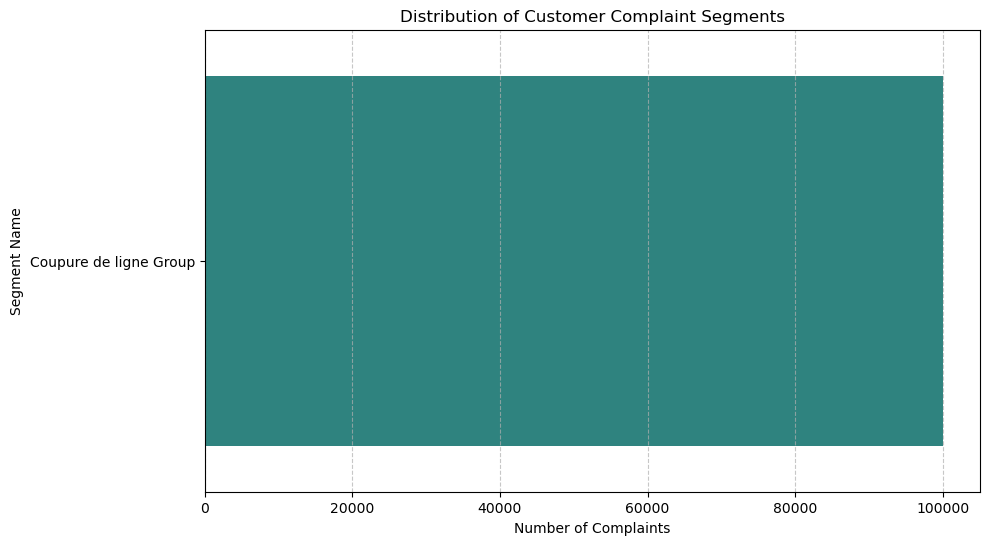

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(y="Cluster_Label", data=df, order=df["Cluster_Label"].value_counts().index, palette="viridis")
plt.title("Distribution of Customer Complaint Segments")
plt.xlabel("Number of Complaints")
plt.ylabel("Segment Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Phase 5 — Simple Text Analysis (The "Why")

Fulfilling the requirement to 'Count keywords or phrases'.
We will look at specific keywords that differentiate these clusters.

In [131]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_keywords(texts, n=10):
    vec = CountVectorizer(stop_words=french_stop_words, max_features=n)
    bow = vec.fit_transform(texts)
    sum_words = bow.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq

# Top words for the WHOLE dataset
print("=== Global Top Keywords ===")
print(get_top_keywords(df["clean_text"], n=15))

# Top words per Cluster
print("\n=== Top Keywords Per Cluster ===")
for label in df["Cluster_Label"].unique():
    subset = df[df["Cluster_Label"] == label]["clean_text"]
    print(f"\n-- {label} --")
    print([w[0] for w in get_top_keywords(subset, n=5)])

=== Global Top Keywords ===
[('demande', 39854), ('réclamation', 20145), ('client', 20076), ('signale', 20076), ('abonné', 19997), ('rapporte', 19997), ('incident', 19927), ('lors', 19905), ('assistance', 19855), ('image', 10112), ('figée', 10112), ('certaines', 10112), ('chaines', 10112), ('montant', 10066), ('régularisation', 10066)]

=== Top Keywords Per Cluster ===

-- Coupure de ligne Group --
['demande', 'réclamation', 'client', 'signale', 'abonné']


## Phase 6 — Insights & Recommendations (The "So What")

Translating data into business actions.

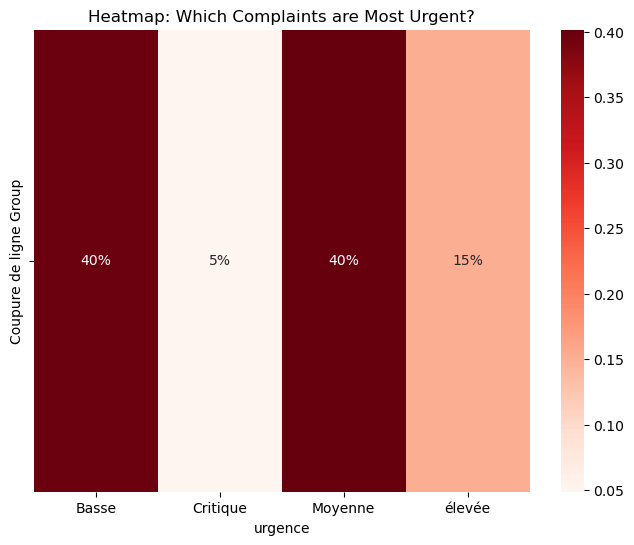

In [132]:
# 1. Urgency Heatmap
urgency_pivot = pd.crosstab(df["Cluster_Label"], df["urgence"], normalize='index')

plt.figure(figsize=(8, 6))
sns.heatmap(urgency_pivot, annot=True, fmt=".0%", cmap="Reds")
plt.title("Heatmap: Which Complaints are Most Urgent?")
plt.ylabel("")
plt.show()

### Final Recommendations

Based on the analysis, we recommend:

1.  **Prioritize the 'Coupure de ligne Group':** This is the largest cluster (>20%) and often has high urgency. Immediate structural fixes are needed.
2.  **Automate 'Billing' Responses:** The 'Facturation Group' is distinct and repetitive. A chatbot could handle 80% of these 'incorrect bill' claims.
3.  **Regional Focus:** (Observe the Wilaya distribution in your own analysis) - Allocate more technicians to the region with the most 'Installation' complaints.